# End-to-End Thesis Pipeline — FAMD + HHO + Weighted Ensemble + Multi-Run

This notebook is a consolidated executable version of the thesis implementation.

Pipeline:
1. Feature engineering
2. Preprocessing
3. FAMD dimensionality reduction
4. Baseline KMeans / Agglomerative / DBSCAN
5. HHO search-space, fitness, optimizer, and health tests
6. HHO Smoke Run — 20 starts, 50 hawks, 60 iterations, all iterations printed
7. HHO Full Run — 30 starts, 80 hawks, 160 iterations, all iterations printed
8. HHO-optimized base clusterers
9. Weighted Ensemble Clustering with learned softmax weights
10. Final weighted co-association consensus and K scan
11. Dedicated Multi-Run HHO + Ensemble — 20 independent starts
12. Convergence plots, fitness bar charts, stability diagnostics, and full-data visualization

**Important:** edit only `DATA_PATH` before `Run All` if the dataset is stored elsewhere.
All code comments are in English. There are no placeholder expressions such as `best = ...`.


## Block 0: Imports, reproducibility, and runtime tracking


In [1]:
import math
import random
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

from prince import FAMD

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster

PIPELINE_START_TIME = time.perf_counter()
PIPELINE_START_DATETIME = datetime.now()

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
rng = np.random.default_rng(RNG_SEED)

print("Pipeline started at:", PIPELINE_START_DATETIME.strftime("%Y-%m-%d %H:%M:%S"))
print("RNG_SEED =", RNG_SEED)


Pipeline started at: 2026-08-25 10:28:06
RNG_SEED = 42


## Block 1: Data loading and missing-value handling


In [2]:
DATA_PATH = Path(r"C:\Users\Sina\Desktop\Thesis\Shopping_Trends_And_Customer_Behaviour_Dataset.csv")

df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

# Remove accidental index/export columns.
unnamed_cols = [c for c in df.columns if c.lower().startswith("unnamed")]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)

# The thesis dataset is unlabeled; all downstream evaluation is unsupervised.
trueLabels = None

# Normalize textual representations of missing values.
MISSING_TOKENS = {"", "na", "n/a", "none", "null", "nan", "-", "?"}
obj_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

for c in obj_cols:
    s = df[c].astype("string").str.strip()
    s = s.mask(s.str.lower().isin(MISSING_TOKENS), pd.NA)
    df[c] = s

missing_per_col = df.isna().sum()
total_missing = int(missing_per_col.sum())

# Impute only when missing values actually exist.
if total_missing > 0:
    numeric_cols_tmp = df.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols_tmp = [c for c in df.columns if c not in numeric_cols_tmp]

    for c in numeric_cols_tmp:
        if df[c].isna().any():
            df[c] = df[c].fillna(df[c].median())

    for c in categorical_cols_tmp:
        if df[c].isna().any():
            mode_val = df[c].mode(dropna=True)
            fill_val = mode_val.iloc[0] if len(mode_val) else "Unknown"
            df[c] = df[c].fillna(fill_val)

print("Loaded from:", DATA_PATH)
print("Dataframe shape:", df.shape)
print("Total missing values after cleaning:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))


Loaded from: C:\Users\Sina\Desktop\Thesis\Shopping_Trends_And_Customer_Behaviour_Dataset.csv
Dataframe shape: (3900, 17)
Total missing values after cleaning: 0
Duplicate rows: 0


## Block 2: Feature engineering


In [3]:
def clean_text_series(s: pd.Series) -> pd.Series:
    """Normalize text spacing while preserving pandas missing values."""
    return s.astype("string").str.strip().str.replace(r"\s+", " ", regex=True)


work = df.copy()

# True reproduces the thesis feature set.
THESIS_EXTRA_FEATURES = True
STRICT_MAPPING = True

# Convert purchase-frequency categories into an approximate interpurchase interval in days.
if "Frequency of Purchases" not in work.columns:
    raise KeyError("Column 'Frequency of Purchases' not found.")

freq_raw = clean_text_series(work["Frequency of Purchases"]).str.lower()
freq_map_days = {
    "daily": 1,
    "weekly": 7,
    "fortnightly": 14,
    "bi-weekly": 14,
    "biweekly": 14,
    "monthly": 30,
    "quarterly": 90,
    "every 3 months": 90,
    "annually": 365,
    "annual": 365,
    "yearly": 365,
}

work["FreqDays"] = freq_raw.map(freq_map_days).astype("Int64")

if work["FreqDays"].isna().any():
    bad_vals = sorted(freq_raw[work["FreqDays"].isna()].dropna().unique().tolist())
    msg = f"Unmapped Frequency values: {bad_vals}. Extend freq_map_days."
    if STRICT_MAPPING:
        raise ValueError(msg)
    fill_val = int(pd.Series(list(freq_map_days.values())).median())
    work["FreqDays"] = work["FreqDays"].fillna(fill_val).astype("Int64")

# Convert Yes/No indicators to binary numeric features.
yn_map = {"yes": 1, "no": 0, "true": 1, "false": 0, "1": 1, "0": 0}
binary_cols = ["Subscription Status", "Discount Applied", "Promo Code Used"]

for c in binary_cols:
    if c not in work.columns:
        raise KeyError(f"Column '{c}' not found.")
    raw = clean_text_series(work[c]).str.lower()
    work[c] = raw.map(yn_map).astype("Int64")

    if work[c].isna().any():
        bad_vals = sorted(raw[work[c].isna()].dropna().unique().tolist())
        msg = f"Unmapped binary values in '{c}': {bad_vals}. Extend yn_map."
        if STRICT_MAPPING:
            raise ValueError(msg)
        mode_val = work[c].mode(dropna=True)
        fill_val = int(mode_val.iloc[0]) if len(mode_val) else 0
        work[c] = work[c].fillna(fill_val).astype("Int64")

base_numeric_cols = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases",
]
extra_numeric_cols = ["FreqDays"] + binary_cols
numeric_cols = base_numeric_cols + (extra_numeric_cols if THESIS_EXTRA_FEATURES else [])

categorical_cols = [
    "Gender",
    "Item Purchased",
    "Category",
    "Location",
    "Color",
    "Season",
    "Shipping Type",
    "Payment Method",
]

for c in categorical_cols:
    if c not in work.columns:
        raise KeyError(f"Column '{c}' not found.")
    work[c] = clean_text_series(work[c])

X_mixed = work[numeric_cols + categorical_cols].copy()

for c in numeric_cols:
    if c in binary_cols or c == "FreqDays":
        X_mixed[c] = X_mixed[c].astype("Int64")
    else:
        X_mixed[c] = pd.to_numeric(X_mixed[c], errors="raise")

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("X_mixed shape:", X_mixed.shape)


Numeric columns: ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases', 'FreqDays', 'Subscription Status', 'Discount Applied', 'Promo Code Used']
Categorical columns: ['Gender', 'Item Purchased', 'Category', 'Location', 'Color', 'Season', 'Shipping Type', 'Payment Method']
X_mixed shape: (3900, 16)


## Block 3: Preprocessing and percentile capping


In [4]:
work_pp = work.copy()

if work_pp.isna().any().any():
    raise ValueError("Missing values detected before preprocessing.")

CAP_LO, CAP_HI = 0.05, 0.95
CAP_FREQDAYS = False
CAP_BINARIES = False

exclude_from_cap = set(binary_cols)
if not CAP_FREQDAYS and "FreqDays" in work_pp.columns:
    exclude_from_cap.add("FreqDays")

continuous_numeric = [c for c in numeric_cols if c not in exclude_from_cap]
clip_report = []
clip_thresholds = {}

for c in continuous_numeric:
    col = pd.to_numeric(work_pp[c], errors="raise").astype(float)
    lo = float(col.quantile(CAP_LO))
    hi = float(col.quantile(CAP_HI))

    before = col.to_numpy()
    after = np.clip(before, lo, hi)
    n_clipped = int(np.sum((before < lo) | (before > hi)))

    work_pp[c] = after
    clip_report.append((c, lo, hi, n_clipped))
    clip_thresholds[c] = {"p05": lo, "p95": hi, "clipped": n_clipped}

X_mixed_pp = work_pp[numeric_cols + categorical_cols].copy()

# This scaled version is retained only for optional numeric comparisons/plots; it is not used by FAMD.
scaler = MinMaxScaler()
X_numeric_norm = scaler.fit_transform(work_pp[numeric_cols].to_numpy(dtype=float))

print("Capping report:")
for c, lo, hi, n_clipped in clip_report:
    print(f"  {c:25s} p05={lo:.3f} p95={hi:.3f} clipped={n_clipped}")


Capping report:
  Age                       p05=20.000 p95=68.000 clipped=305
  Purchase Amount (USD)     p05=23.000 p95=96.050 clipped=337
  Review Rating             p05=2.600 p95=4.900 clipped=134
  Previous Purchases        p05=3.000 p95=48.000 clipped=290


## Block 4: FAMD dimensionality reduction


In [5]:
# FAMD directly handles mixed numerical and categorical data in a common latent space.
df_famd = X_mixed_pp.copy(deep=True)

for c in categorical_cols:
    df_famd[c] = df_famd[c].astype("string").str.strip().astype("category")

N_COMPONENTS_FAMD = 3
famd = FAMD(n_components=N_COMPONENTS_FAMD, random_state=RNG_SEED)
X_reduced = famd.fit_transform(df_famd)
X_red_np = X_reduced.to_numpy() if hasattr(X_reduced, "to_numpy") else np.asarray(X_reduced)

comp_cols = [f"Comp{i}" for i in range(1, N_COMPONENTS_FAMD + 1)]
comp_df = pd.DataFrame(X_red_np, columns=comp_cols, index=X_mixed_pp.index)

print("FAMD reduced shape:", X_red_np.shape)

# Report global inertia only through Prince's explicit global-variance attributes.
if hasattr(famd, "percentage_of_variance_") and hasattr(famd, "cumulative_percentage_of_variance_"):
    famd_inertia_df = pd.DataFrame({
        "Component": comp_cols,
        "Eigenvalue": famd.eigenvalues_[:N_COMPONENTS_FAMD],
        "Percentage_of_Inertia": famd.percentage_of_variance_[:N_COMPONENTS_FAMD],
        "Cumulative_Percentage_of_Inertia": famd.cumulative_percentage_of_variance_[:N_COMPONENTS_FAMD],
    })
    print(famd_inertia_df)
    print(
        "Cumulative global inertia for first 3 components:",
        float(famd_inertia_df["Cumulative_Percentage_of_Inertia"].iloc[-1]),
    )


FAMD reduced shape: (3900, 3)
  Component  Eigenvalue  Percentage_of_Inertia  \
0     Comp1   18.363694               2.515574   
1     Comp2   11.974452               1.640336   
2     Comp3   11.680896               1.600123   

   Cumulative_Percentage_of_Inertia  
0                          2.515574  
1                          4.155910  
2                          5.756033  
Cumulative global inertia for first 3 components: 5.756033084394645


## Block 5: Eta-squared categorical effect sizes


In [6]:
def eta_squared(cat: pd.Series, y: pd.Series) -> float:
    """Compute eta-squared: proportion of numeric variance explained by a categorical variable."""
    temp = pd.DataFrame({"cat": cat.astype("string"), "y": y}).dropna()
    if temp["cat"].nunique() < 2:
        return 0.0

    grand_mean = temp["y"].mean()
    ss_between = temp.groupby("cat")["y"].apply(
        lambda g: len(g) * (g.mean() - grand_mean) ** 2
    ).sum()
    ss_total = ((temp["y"] - grand_mean) ** 2).sum()
    return float(ss_between / ss_total) if ss_total > 0 else 0.0


def categorical_effects_table(cat_cols):
    rows = []
    for c in cat_cols:
        rows.append({
            "CategoricalFeature": c,
            "eta2_Comp1": eta_squared(work_pp[c], comp_df["Comp1"]),
            "eta2_Comp2": eta_squared(work_pp[c], comp_df["Comp2"]),
            "eta2_Comp3": eta_squared(work_pp[c], comp_df["Comp3"]),
            "n_unique": int(work_pp[c].nunique(dropna=True)),
        })
    return pd.DataFrame(rows).sort_values("eta2_Comp1", ascending=False).reset_index(drop=True)


effects = categorical_effects_table(categorical_cols)
print(effects)


  CategoricalFeature  eta2_Comp1  eta2_Comp2  eta2_Comp3  n_unique
0             Gender    0.525353    0.000146    0.000941         2
1           Location    0.025817    0.057818    0.055388        50
2     Item Purchased    0.018339    0.959827    0.954728        25
3              Color    0.011408    0.042356    0.036375        25
4     Payment Method    0.003247    0.002519    0.004752         6
5      Shipping Type    0.002896    0.005956    0.003795         6
6           Category    0.002251    0.955772    0.945271         4
7             Season    0.001602    0.004761    0.003049         4


## Block 6: Safe clustering metrics


In [7]:
def _core_mask(labels, min_core=10):
    """Return valid non-noise mask; return None for degenerate clusterings."""
    labels = np.asarray(labels)

    if np.any(labels == -1):
        core = labels >= 0
        if core.sum() < min_core:
            return None
        if len(np.unique(labels[core])) < 2:
            return None
        return core

    if len(np.unique(labels)) < 2:
        return None

    return np.ones_like(labels, dtype=bool)


def safe_silhouette(X, labels, min_core=10, on_core_if_noise=True):
    try:
        labels = np.asarray(labels)
        if on_core_if_noise:
            mask = _core_mask(labels, min_core=min_core)
            if mask is None:
                return -1.0
            return float(silhouette_score(X[mask], labels[mask]))

        if len(np.unique(labels)) < 2:
            return -1.0
        return float(silhouette_score(X, labels))
    except Exception:
        return -1.0


def safe_dbi(X, labels, min_core=10, on_core_if_noise=True):
    try:
        labels = np.asarray(labels)
        if on_core_if_noise:
            mask = _core_mask(labels, min_core=min_core)
            if mask is None:
                return float("inf")
            return float(davies_bouldin_score(X[mask], labels[mask]))

        if len(np.unique(labels)) < 2:
            return float("inf")
        return float(davies_bouldin_score(X, labels))
    except Exception:
        return float("inf")


def safe_ch(X, labels, min_core=10, on_core_if_noise=True):
    try:
        labels = np.asarray(labels)
        if on_core_if_noise:
            mask = _core_mask(labels, min_core=min_core)
            if mask is None:
                return -1.0
            return float(calinski_harabasz_score(X[mask], labels[mask]))

        if len(np.unique(labels)) < 2:
            return -1.0
        return float(calinski_harabasz_score(X, labels))
    except Exception:
        return -1.0


def metrics_dict(X, labels, min_core=10, noise_penalty=0.50, dbi_penalty=1.00):
    """Return core metrics plus noise-penalized metrics for DBSCAN."""
    labels = np.asarray(labels)
    has_noise = np.any(labels == -1)
    noise_ratio = float(np.mean(labels == -1)) if has_noise else 0.0

    core_labels = labels[labels >= 0] if has_noise else labels
    n_clusters = int(len(set(core_labels))) if core_labels.size else 0

    sil_core = safe_silhouette(X, labels, min_core=min_core, on_core_if_noise=True)
    dbi_core = safe_dbi(X, labels, min_core=min_core, on_core_if_noise=True)
    ch_core = safe_ch(X, labels, min_core=min_core, on_core_if_noise=True)

    sil_pen = sil_core - noise_penalty * noise_ratio if sil_core != -1.0 else -1.0
    dbi_pen = dbi_core * (1.0 + dbi_penalty * noise_ratio) if np.isfinite(dbi_core) else float("inf")

    core_mask = labels >= 0 if has_noise else np.ones_like(labels, dtype=bool)
    core_size = int(core_mask.sum())
    min_cluster_size = None
    if core_size > 0 and n_clusters > 0:
        _, cnt = np.unique(labels[core_mask], return_counts=True)
        min_cluster_size = int(cnt.min())

    return {
        "sil_core": sil_core,
        "dbi_core": dbi_core,
        "ch_core": ch_core,
        "sil_pen": sil_pen,
        "dbi_pen": dbi_pen,
        "n_clusters": n_clusters,
        "noise_ratio": noise_ratio,
        "core_size": core_size,
        "min_cluster_size": min_cluster_size,
    }


def safe_metrics(X, labels, min_core=30):
    """NaN-safe tuple wrapper used by the HHO fitness."""
    mask = _core_mask(labels, min_core=min_core)
    if mask is None:
        return np.nan, np.nan, np.nan

    Xc = np.asarray(X)[mask]
    yc = np.asarray(labels)[mask]

    try:
        sil = float(silhouette_score(Xc, yc))
    except Exception:
        sil = np.nan
    try:
        dbi = float(davies_bouldin_score(Xc, yc))
    except Exception:
        dbi = np.nan
    try:
        ch = float(calinski_harabasz_score(Xc, yc))
    except Exception:
        ch = np.nan

    return sil, dbi, ch


## Block 7: Baseline clustering


In [8]:
X = X_red_np
K_SCAN = list(range(2, 13))

# KMeans baseline: choose K by maximum silhouette.
kmeans_scan = []
for k in K_SCAN:
    labels = KMeans(
        n_clusters=k,
        n_init=20,
        max_iter=500,
        random_state=RNG_SEED,
    ).fit_predict(X)
    kmeans_scan.append(safe_silhouette(X, labels, on_core_if_noise=False))

bestK = K_SCAN[int(np.argmax(kmeans_scan))]
kmeans_labels = KMeans(
    n_clusters=bestK,
    n_init=30,
    max_iter=500,
    random_state=RNG_SEED,
).fit_predict(X)

# Agglomerative baseline: scan K independently using Ward linkage.
agglo_scan = []
for k in K_SCAN:
    labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X)
    agglo_scan.append(safe_silhouette(X, labels, on_core_if_noise=False))

bestK_agglo = K_SCAN[int(np.argmax(agglo_scan))]
agglo_labels = AgglomerativeClustering(
    n_clusters=bestK_agglo,
    linkage="ward",
).fit_predict(X)

# Optional spectral baseline used only as a comparison, not in the final ensemble.
RUN_SPECTRAL = True
spectral_labels = None
if RUN_SPECTRAL:
    try:
        spectral_labels = SpectralClustering(
            n_clusters=bestK,
            affinity="nearest_neighbors",
            n_neighbors=70,
            random_state=RNG_SEED,
            assign_labels="kmeans",
        ).fit_predict(X)
    except Exception:
        spectral_labels = SpectralClustering(
            n_clusters=bestK,
            affinity="rbf",
            gamma=1.0,
            random_state=RNG_SEED,
            assign_labels="kmeans",
        ).fit_predict(X)

# DBSCAN baseline: search eps from k-distance quantiles for several min_samples values.
min_samples_candidates = [3, 5, 7, 9, 12]
MAX_NOISE_RATIO = 0.25
MIN_CLUSTER_SIZE = 30
min_core_baseline = max(10, int(0.02 * X.shape[0]))

best_db_score = -np.inf
best_eps = None
best_min_samples = None
best_db_labels = None
best_db_metrics = None

for ms in min_samples_candidates:
    nn = NearestNeighbors(n_neighbors=ms, metric="euclidean").fit(X)
    dists, _ = nn.kneighbors(X)
    kdist = dists[:, -1]

    eps_candidates = np.unique(np.quantile(kdist, np.linspace(0.05, 0.95, 25)))
    eps_candidates = eps_candidates[eps_candidates > 0]

    for eps in eps_candidates:
        labels = DBSCAN(eps=float(eps), min_samples=int(ms)).fit_predict(X)
        n_clusters = int(len(set(labels) - {-1}))
        if n_clusters < 2:
            continue

        noise_ratio = float(np.mean(labels == -1)) if np.any(labels == -1) else 0.0
        if noise_ratio > MAX_NOISE_RATIO:
            continue

        core_mask = labels >= 0
        _, counts = np.unique(labels[core_mask], return_counts=True)
        if counts.size == 0 or int(counts.min()) < MIN_CLUSTER_SIZE:
            continue

        md = metrics_dict(X, labels, min_core=min_core_baseline)
        if md["sil_pen"] == -1.0 or not np.isfinite(md["dbi_pen"]):
            continue

        score = md["sil_pen"] - 0.03 * md["dbi_pen"]
        if np.isfinite(score) and score > best_db_score:
            best_db_score = score
            best_eps = float(eps)
            best_min_samples = int(ms)
            best_db_labels = labels.copy()
            best_db_metrics = md.copy()

if best_db_labels is None:
    raise RuntimeError("No valid DBSCAN baseline solution was found.")

dbscan_labels = best_db_labels

# Directly connect the baseline outputs to the HHO reference parameters.
BASELINE_PARAMS = (bestK, best_eps, best_min_samples, bestK_agglo)

print("Baseline parameters:", BASELINE_PARAMS)
print("KMeans metrics:", safe_metrics(X, kmeans_labels, min_core=30))
print("Agglo metrics:", safe_metrics(X, agglo_labels, min_core=30))
print("DBSCAN metrics:", safe_metrics(X, dbscan_labels, min_core=30))
print("DBSCAN noise ratio:", float(np.mean(dbscan_labels == -1)))


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\manifold\_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Baseline parameters: (6, 0.8773458793507984, 12, 6)
KMeans metrics: (0.7119110873414671, 0.40806048920344073, 11588.441693284181)
Agglo metrics: (0.7119110873414671, 0.40806048920344073, 11588.441693284181)
DBSCAN metrics: (0.6927552036977961, 0.5199160359032272, 10061.858424804554)
DBSCAN noise ratio: 0.004871794871794872


## Block 8: HHO search space, data-driven eps bounds, and encoder/decoder


In [9]:
K_MIN, K_MAX = 2, 12
MINPTS_MIN, MINPTS_MAX = 3, 25
NAGG_MIN, NAGG_MAX = 2, 12
MINPTS_LIST = list(range(MINPTS_MIN, MINPTS_MAX + 1))


def build_eps_bounds(
    X,
    minpts_list,
    q_low=0.05,
    q_high=0.95,
    expand_lo=0.80,
    expand_hi=1.30,
    seed=0,
    floor_frac=0.001,
    gap_frac=0.05,
):
    """Build a data-driven eps interval for every minPts value."""
    X = np.asarray(X)
    local_rng = np.random.default_rng(seed)

    idx = np.arange(X.shape[0])
    local_rng.shuffle(idx)
    Xw = X[idx]

    bounds = {}
    for mp in minpts_list:
        k = int(max(2, min(mp, Xw.shape[0] - 1)))
        nn = NearestNeighbors(n_neighbors=k).fit(Xw)
        dists, _ = nn.kneighbors(Xw, return_distance=True)
        kth = dists[:, -1]

        pos = kth[np.isfinite(kth) & (kth > 0)]
        scale = float(np.median(pos)) if pos.size else float(np.nanmax(kth))
        if not np.isfinite(scale) or scale <= 0:
            scale = 1.0

        eps_floor = floor_frac * scale
        lo = float(np.quantile(kth, q_low))
        hi = float(np.quantile(kth, q_high))

        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            lo = float(np.nanmin(kth))
            hi = float(np.nanmax(kth))

        lo = max(eps_floor, lo * expand_lo)
        hi = max(hi * expand_hi, lo * (1.0 + gap_frac))
        bounds[int(mp)] = (float(lo), float(hi))

    return bounds


def decode_solution(sol, eps_bounds_by_minpts):
    """Decode HHO vector [k, log(eps), minPts, nAgg] into legal parameters."""
    sol = np.asarray(sol, dtype=float)

    k = int(np.clip(np.round(sol[0]), K_MIN, K_MAX))
    minPts = int(np.clip(np.round(sol[2]), MINPTS_MIN, MINPTS_MAX))
    nAgg = int(np.clip(np.round(sol[3]), NAGG_MIN, NAGG_MAX))

    lo, hi = eps_bounds_by_minpts[minPts]
    log_eps = float(np.clip(sol[1], math.log(lo), math.log(hi)))
    eps = float(math.exp(log_eps))

    return k, eps, minPts, nAgg


def encode_solution(k, eps, minPts, nAgg, eps_bounds_by_minpts):
    """Encode legal parameters back into the continuous HHO vector."""
    lo, hi = eps_bounds_by_minpts[int(minPts)]
    eps = float(np.clip(float(eps), float(lo), float(hi)))
    return np.array([float(k), math.log(eps), float(minPts), float(nAgg)], dtype=float)


## Block 9: Final soft-tradeoff HHO fitness


In [10]:
def make_fitness_soft_tradeoff(
    Xfit,
    eps_bounds_by_minpts,
    baseline_params,
    tol_sil_soft=0.02,
    tol_dbi_soft=0.05,
    tol_ch_soft=300.0,
    BIG_M=20.0,
    min_core=30,
    require_dbscan_min_clusters=2,
    w_sil=1.0,
    w_dbi=1.0,
    w_ch=0.35,
    wK=1.5,
    wA=1.5,
    wD=1.0,
    invalid_extra_penalty=3.0,
    noise_penalty=2.0,
    max_noise=0.05,
):
    """
    Create the soft-tradeoff objective used by the final HHO run.
    Lower fitness is better.
    """
    Xfit = np.asarray(Xfit)
    min_core_for_met = max(min_core, int(0.05 * Xfit.shape[0]))
    BIG_F = BIG_M * 1000.0

    cache_k, cache_a, cache_d, cache_m = {}, {}, {}, {}

    def labels_kmeans(k):
        if k not in cache_k:
            cache_k[k] = KMeans(
                n_clusters=k,
                n_init=10,
                max_iter=300,
                random_state=0,
            ).fit_predict(Xfit)
        return cache_k[k]

    def labels_agglo(nAgg):
        if nAgg not in cache_a:
            cache_a[nAgg] = AgglomerativeClustering(
                n_clusters=nAgg,
                linkage="ward",
            ).fit_predict(Xfit)
        return cache_a[nAgg]

    def labels_dbscan(eps, minPts):
        eps_r = round(float(eps), 6)
        key = (eps_r, int(minPts))
        if key not in cache_d:
            cache_d[key] = DBSCAN(
                eps=eps_r,
                min_samples=int(minPts),
            ).fit_predict(Xfit)
        return cache_d[key], eps_r

    def metrics(tag, key, labels):
        mk = (tag, key)
        if mk not in cache_m:
            cache_m[mk] = safe_metrics(Xfit, labels, min_core=min_core_for_met)
        return cache_m[mk]

    def dbscan_cluster_count(labels):
        core = np.asarray(labels)
        core = core[core >= 0]
        return int(len(np.unique(core))) if core.size else 0

    def dbscan_noise_ratio(labels):
        y = np.asarray(labels)
        return float(np.mean(y == -1)) if np.any(y == -1) else 0.0

    k0, eps0, minPts0, nAgg0 = baseline_params
    lab_k0 = labels_kmeans(int(k0))
    lab_a0 = labels_agglo(int(nAgg0))
    lab_d0, eps0_r = labels_dbscan(float(eps0), int(minPts0))

    sil0_k, dbi0_k, ch0_k = metrics("K0", int(k0), lab_k0)
    sil0_a, dbi0_a, ch0_a = metrics("A0", int(nAgg0), lab_a0)
    sil0_d, dbi0_d, ch0_d = metrics("D0", (eps0_r, int(minPts0)), lab_d0)

    for name, vals in {
        "KMeans baseline": (sil0_k, dbi0_k, ch0_k),
        "Agglo baseline": (sil0_a, dbi0_a, ch0_a),
        "DBSCAN baseline": (sil0_d, dbi0_d, ch0_d),
    }.items():
        if not all(np.isfinite(v) for v in vals):
            raise ValueError(f"{name} metrics are invalid on this HHO sample.")

    def objective_score(sil, dbi, ch, sil0, dbi0, ch0):
        invalid = not all(np.isfinite(v) for v in (sil, dbi, ch))
        if invalid:
            return 0.0, True

        t_sil = float(sil - sil0)
        t_dbi = float((dbi0 - dbi) / max(abs(float(dbi0)), 0.1))
        t_ch = float(math.log1p(max(ch, 0.0)) - math.log1p(max(ch0, 0.0)))
        return w_sil * t_sil + w_dbi * t_dbi + w_ch * t_ch, False

    def soft_penalty(sil, dbi, ch, sil0, dbi0, ch0):
        p = 0.0
        p += 1.0 if not np.isfinite(sil) else max(0.0, (sil0 - sil) - tol_sil_soft)
        p += 1.0 if not np.isfinite(dbi) else max(0.0, (dbi - dbi0) - tol_dbi_soft)
        p += 1.0 if not np.isfinite(ch) else max(0.0, (ch0 - ch) - tol_ch_soft) / max(100.0, float(ch0))
        return float(p)

    def fitness(sol):
        try:
            k, eps, minPts, nAgg = decode_solution(sol, eps_bounds_by_minpts)

            lab_k = labels_kmeans(k)
            lab_a = labels_agglo(nAgg)
            lab_d, eps_r = labels_dbscan(eps, minPts)

            sil_k, dbi_k, ch_k = metrics("K", k, lab_k)
            sil_a, dbi_a, ch_a = metrics("A", nAgg, lab_a)
            sil_d, dbi_d, ch_d = metrics("D", (eps_r, minPts), lab_d)

            sk, invk = objective_score(sil_k, dbi_k, ch_k, sil0_k, dbi0_k, ch0_k)
            sa, inva = objective_score(sil_a, dbi_a, ch_a, sil0_a, dbi0_a, ch0_a)
            sd, invd = objective_score(sil_d, dbi_d, ch_d, sil0_d, dbi0_d, ch0_d)

            pen = 0.0
            pen += soft_penalty(sil_k, dbi_k, ch_k, sil0_k, dbi0_k, ch0_k)
            pen += soft_penalty(sil_a, dbi_a, ch_a, sil0_a, dbi0_a, ch0_a)
            pen += soft_penalty(sil_d, dbi_d, ch_d, sil0_d, dbi0_d, ch0_d)
            pen += invalid_extra_penalty * (int(invk) + int(inva) + int(invd))

            if require_dbscan_min_clusters is not None:
                ncl = dbscan_cluster_count(lab_d)
                if ncl < int(require_dbscan_min_clusters):
                    pen += float(int(require_dbscan_min_clusters) - ncl)

            nr = dbscan_noise_ratio(lab_d)
            pen += noise_penalty * max(0.0, nr - max_noise)

            score = (wK * sk + wA * sa + wD * sd) / (wK + wA + wD)
            score = float(np.clip(score, -5.0, 5.0))

            # Shift keeps the fitness positive without changing the minimizer.
            val = float(BIG_M * pen - score + 6.0)
            return val if np.isfinite(val) else BIG_F

        except Exception:
            return BIG_F

    baseline_info = {
        "params": (k0, eps0, minPts0, nAgg0),
        "KMeans": (sil0_k, dbi0_k, ch0_k),
        "Agglo": (sil0_a, dbi0_a, ch0_a),
        "DBSCAN": (sil0_d, dbi0_d, ch0_d),
    }
    return fitness, baseline_info


## Block 10: HHO optimizer core


In [11]:
def levy_flight(dim, beta=1.5, rng=None):
    """Generate a Levy-flight step used to escape local optima."""
    rng = np.random.default_rng() if rng is None else rng
    sigma_u = (
        math.gamma(1 + beta)
        * math.sin(math.pi * beta / 2)
        / (math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2))
    ) ** (1 / beta)
    u = rng.normal(0, sigma_u, size=dim)
    v = rng.normal(0, 1, size=dim)
    return u / (np.abs(v) ** (1 / beta))


def run_hho_once(
    fobj,
    dim=4,
    pop_size=35,
    max_iter=60,
    seed=1,
    patience=6,
    restart_frac=0.50,
    diversify_every=6,
    diversify_frac=0.25,
    mut_sigma=0.12,
    local_probe_every=5,
    LB=None,
    UB=None,
    init_center=None,
    init_spread=0.18,
):
    """Run one HHO start and return the best solution, best fitness, and convergence trace."""
    local_rng = np.random.default_rng(seed)
    LB = np.asarray(LB, dtype=float)
    UB = np.asarray(UB, dtype=float)

    if not np.all(np.isfinite(LB)) or not np.all(np.isfinite(UB)):
        raise ValueError("LB/UB contain NaN or Inf.")
    if np.any(UB <= LB):
        raise ValueError("Each upper bound must exceed its lower bound.")

    BIG_F = 1e12

    def safe_f(x):
        val = float(fobj(x))
        return val if np.isfinite(val) else BIG_F

    population = LB + local_rng.random((pop_size, dim)) * (UB - LB)
    if init_center is not None:
        center = np.asarray(init_center, dtype=float)
        population = np.clip(
            center + local_rng.normal(0, init_spread, size=(pop_size, dim)) * (UB - LB),
            LB,
            UB,
        )

    fitness_values = np.array([safe_f(population[i]) for i in range(pop_size)], dtype=float)
    best_idx = int(np.argmin(fitness_values))
    X_best = population[best_idx].copy()
    F_best = float(fitness_values[best_idx])

    trace = np.full(max_iter, np.nan, dtype=float)
    trace[0] = F_best
    last_improve = 1

    for t in range(2, max_iter + 1):
        X_mean = population.mean(axis=0)
        E0 = 2.0 * local_rng.random() - 1.0
        E = 2.0 * E0 * (1.0 - t / max_iter)

        for i in range(pop_size):
            Xi = population[i].copy()
            q = local_rng.random()
            r = local_rng.random()
            J = 2.0 * (1.0 - local_rng.random())

            if abs(E) >= 1.0:
                # Exploration phase.
                j = int(local_rng.integers(0, pop_size))
                Xrand = population[j]
                if q < 0.5:
                    Xnew = Xrand - local_rng.random(dim) * np.abs(
                        Xrand - 2.0 * local_rng.random(dim) * Xi
                    )
                else:
                    Xnew = (X_best - X_mean) - local_rng.random(dim) * (
                        LB + local_rng.random(dim) * (UB - LB)
                    )
            else:
                # Exploitation phase.
                if r >= 0.5 and abs(E) < 0.5:
                    Xnew = X_best - E * np.abs(J * X_best - Xi)
                elif r >= 0.5 and abs(E) >= 0.5:
                    Xnew = X_best - E * np.abs(X_best - Xi)
                else:
                    Y = X_best - E * np.abs(J * X_best - Xi)
                    Z = Y + 0.02 * levy_flight(dim, beta=1.5, rng=local_rng) * (UB - LB)
                    Y = np.clip(Y, LB, UB)
                    Z = np.clip(Z, LB, UB)
                    Xnew = Y if safe_f(Y) <= safe_f(Z) else Z

            # Mutation adds controlled stochastic movement.
            if local_rng.random() < 0.40:
                Xnew = Xnew + local_rng.normal(0.0, mut_sigma, size=dim) * (UB - LB)

            Xnew = np.clip(Xnew, LB, UB)
            fnew = safe_f(Xnew)

            if fnew < fitness_values[i]:
                population[i] = Xnew
                fitness_values[i] = fnew

            if fitness_values[i] < F_best - 1e-12:
                F_best = float(fitness_values[i])
                X_best = population[i].copy()
                last_improve = t

        # Local probe around the current best solution.
        if local_probe_every and t % int(local_probe_every) == 0:
            probes = 10
            candidates = np.clip(
                X_best + local_rng.normal(0, mut_sigma * 0.6, size=(probes, dim)) * (UB - LB),
                LB,
                UB,
            )
            candidate_f = np.array([safe_f(c) for c in candidates], dtype=float)
            jbest = int(np.argmin(candidate_f))
            if candidate_f[jbest] < F_best - 1e-12:
                F_best = float(candidate_f[jbest])
                X_best = candidates[jbest].copy()
                last_improve = t

        # Periodically diversify the worst solutions.
        if diversify_every and t % int(diversify_every) == 0:
            m = max(1, int(diversify_frac * pop_size))
            worst = np.argsort(fitness_values)[-m:]
            population[worst] = LB + local_rng.random((m, dim)) * (UB - LB)
            fitness_values[worst] = np.array([safe_f(population[w]) for w in worst], dtype=float)

        # Restart the worst part of the population after stagnation.
        if t - last_improve >= int(patience):
            m = max(1, int(restart_frac * pop_size))
            worst = np.argsort(fitness_values)[-m:]
            population[worst] = np.clip(
                X_best + local_rng.normal(0, init_spread, size=(m, dim)) * (UB - LB),
                LB,
                UB,
            )
            fitness_values[worst] = np.array([safe_f(population[w]) for w in worst], dtype=float)
            last_improve = t

        trace[t - 1] = F_best

    return {"best_sol": X_best, "best_fit": F_best, "trace": trace}


HHO_DEFAULTS = {
    "mut_sigma": 0.16,
    "diversify_every": 5,
    "diversify_frac": 0.30,
    "restart_frac": 0.45,
    "patience": 6,
    "local_probe_every": 3,
}


## Block 11: HHO runner helpers, Path-B penalties, full-data evaluator, and plotting utilities


In [12]:
W_SIL, W_DBI, W_CH = 1.2, 1.1, 0.20

EPS_HUG_THR = 0.85
PEN_EPS_HUG = 8.0
NCLUST_MIN = 6
PEN_NCLUST = 2.0


def make_LBUB_from_eps_bounds(eps_bounds_by_minpts):
    all_los = [eps_bounds_by_minpts[m][0] for m in MINPTS_LIST]
    all_his = [eps_bounds_by_minpts[m][1] for m in MINPTS_LIST]
    eps_lo_g = float(np.min(all_los))
    eps_hi_g = float(np.max(all_his))

    LB = np.array([K_MIN, math.log(eps_lo_g), MINPTS_MIN, NAGG_MIN], dtype=float)
    UB = np.array([K_MAX, math.log(eps_hi_g), MINPTS_MAX, NAGG_MAX], dtype=float)
    return LB, UB


def _labels_kmeans(X, k):
    return KMeans(n_clusters=int(k), n_init=20, max_iter=500, random_state=0).fit_predict(X)


def _labels_agglo(X, nAgg):
    return AgglomerativeClustering(n_clusters=int(nAgg), linkage="ward").fit_predict(X)


def _labels_dbscan(X, eps, minPts):
    eps_r = round(float(eps), 6)
    return DBSCAN(eps=eps_r, min_samples=int(minPts)).fit_predict(X), eps_r


def evaluate_solution_on_full(X_full, sol_vec, eps_bounds_by_minpts, min_core=30):
    opt_k, opt_eps, opt_minPts, opt_nAgg = decode_solution(sol_vec, eps_bounds_by_minpts)

    lab_k = _labels_kmeans(X_full, opt_k)
    lab_a = _labels_agglo(X_full, opt_nAgg)
    lab_d, eps_r = _labels_dbscan(X_full, opt_eps, opt_minPts)

    sk, dk, ck = safe_metrics(X_full, lab_k, min_core=min_core)
    sa, da, ca = safe_metrics(X_full, lab_a, min_core=min_core)
    sd, dd, cd = safe_metrics(X_full, lab_d, min_core=min_core)

    y = np.asarray(lab_d)
    noise_ratio = float(np.mean(y == -1)) if np.any(y == -1) else 0.0
    core = y[y >= 0]
    n_clusters = int(len(np.unique(core))) if core.size else 0

    min_cluster = None
    if core.size:
        _, cnt = np.unique(core, return_counts=True)
        min_cluster = int(cnt.min())

    return {
        "opt_k": int(opt_k),
        "opt_eps": float(opt_eps),
        "opt_eps_rounded": float(eps_r),
        "opt_minPts": int(opt_minPts),
        "opt_nAgg": int(opt_nAgg),
        "KMeans": {"Sil": sk, "DBI": dk, "CH": ck},
        "Agglo": {"Sil": sa, "DBI": da, "CH": ca},
        "DBSCAN": {"Sil": sd, "DBI": dd, "CH": cd},
        "DBSCAN_diag": {
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "core_size": int(np.sum(y >= 0)),
            "min_cluster_size": min_cluster,
        },
    }


def repair_baseline_params_for_sample(
    Xfit,
    baseline_params,
    eps_bounds_by_minpts,
    min_core=30,
    minPts_candidates=None,
    eps_grid_n=9,
):
    """Repair the DBSCAN baseline on a small HHO sample if its metrics become undefined."""
    k0, eps0, minPts0, nAgg0 = baseline_params
    k0, minPts0, nAgg0 = int(k0), int(minPts0), int(nAgg0)

    if minPts_candidates is None:
        candidates = [
            minPts0 - 4,
            minPts0 - 2,
            minPts0,
            minPts0 + 2,
            minPts0 + 4,
            5,
            8,
            10,
            12,
            15,
            18,
            20,
            25,
        ]
        minPts_candidates = sorted({m for m in candidates if MINPTS_MIN <= m <= MINPTS_MAX})

    def dbscan_metrics_ok(eps, m):
        labels, _ = _labels_dbscan(Xfit, eps, m)
        return all(np.isfinite(v) for v in safe_metrics(Xfit, labels, min_core=min_core))

    lo0, hi0 = eps_bounds_by_minpts[minPts0]
    eps0c = float(np.clip(float(eps0), float(lo0), float(hi0)))
    if dbscan_metrics_ok(eps0c, minPts0):
        return k0, eps0c, minPts0, nAgg0

    for m in minPts_candidates:
        lo, hi = eps_bounds_by_minpts[int(m)]
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            continue

        grid = np.linspace(lo, hi, num=int(eps_grid_n))
        grid = sorted(grid, key=lambda e: abs(float(e) - float(eps0)))
        for e in grid:
            if dbscan_metrics_ok(e, int(m)):
                return k0, float(e), int(m), nAgg0

    raise ValueError("Could not repair the baseline DBSCAN on this sample.")


def wrap_fitness_pathB(fitness_base, Xfit, eps_bounds_by_minpts):
    """Add the final anti-overmerge penalties used by Path-B."""
    def wrapped(sol_vec):
        base = float(fitness_base(sol_vec))
        _, eps, minPts, _ = decode_solution(sol_vec, eps_bounds_by_minpts)
        _, hi = eps_bounds_by_minpts[int(minPts)]

        penalty = 0.0

        if hi > 0 and float(eps) >= EPS_HUG_THR * float(hi):
            penalty += PEN_EPS_HUG * (float(eps) / float(hi))

        lab_d, _ = _labels_dbscan(Xfit, eps, minPts)
        core = np.asarray(lab_d)
        core = core[core >= 0]
        n_clusters = int(len(np.unique(core))) if core.size else 0

        if n_clusters <= 0:
            penalty += PEN_NCLUST * NCLUST_MIN
        elif n_clusters < NCLUST_MIN:
            penalty += PEN_NCLUST * (NCLUST_MIN - n_clusters)

        return base + penalty

    return wrapped

def hho_multistart(
    X_full,
    baseline_params,
    sample_n=400,
    n_starts=20,
    base_seed=1,
    pop_size=50,
    max_iter=60,
    w_sil=W_SIL,
    w_dbi=W_DBI,
    w_ch=W_CH,
    q_low=0.02,
    q_high=0.98,
    expand_lo=0.65,
    expand_hi=1.80,
    min_core=40,
    print_all_iterations=False,
    stage_name='HHO',
):
    """Run independent HHO starts and store every convergence trace.

    When print_all_iterations=True, every iteration of every start is printed.
    This is used for the thesis Smoke and Full runs.
    """
    t0 = time.time()
    runs = []
    best_run = None

    X_full = np.asarray(X_full)
    N = int(X_full.shape[0])
    sample_n_eff = int(min(sample_n, N))

    for start_idx in range(int(n_starts)):
        seed = int(base_seed + start_idx)
        local_rng = np.random.default_rng(seed)

        sample_idx = local_rng.choice(N, size=sample_n_eff, replace=False)
        Xfit = X_full[sample_idx]

        eps_bounds = build_eps_bounds(
            Xfit,
            minpts_list=MINPTS_LIST,
            q_low=q_low,
            q_high=q_high,
            expand_lo=expand_lo,
            expand_hi=expand_hi,
            seed=seed,
        )

        baseline_sample = repair_baseline_params_for_sample(
            Xfit,
            baseline_params,
            eps_bounds,
            min_core=min_core,
        )

        fitness_base, baseline_info_local = make_fitness_soft_tradeoff(
            Xfit=Xfit,
            eps_bounds_by_minpts=eps_bounds,
            baseline_params=baseline_sample,
            w_sil=w_sil,
            w_dbi=w_dbi,
            w_ch=w_ch,
            min_core=min_core,
        )
        fitness = wrap_fitness_pathB(fitness_base, Xfit, eps_bounds)

        LB, UB = make_LBUB_from_eps_bounds(eps_bounds)
        if not np.all(np.isfinite(LB)) or not np.all(np.isfinite(UB)):
            raise ValueError('LB/UB contain non-finite values.')
        if np.any(UB <= LB):
            raise ValueError('Every HHO upper bound must be greater than its lower bound.')

        k0, eps0, minPts0, nAgg0 = baseline_sample
        init_center = np.array(
            [float(k0), math.log(float(eps0)), float(minPts0), float(nAgg0)],
            dtype=float,
        )

        print('\n' + '=' * 72)
        print(
            f'{stage_name} | START {start_idx + 1}/{n_starts} | seed={seed} | '
            f'sample_n={sample_n_eff} | pop={pop_size} | iterations={max_iter}'
        )
        print('=' * 72)

        out = run_hho_once(
            fobj=fitness,
            dim=4,
            pop_size=int(pop_size),
            max_iter=int(max_iter),
            seed=seed,
            LB=LB,
            UB=UB,
            init_center=init_center,
            **HHO_DEFAULTS,
        )

        trace = np.asarray(out['trace'], dtype=float).reshape(-1)
        if trace.size != int(max_iter):
            raise RuntimeError(
                f'Expected {max_iter} trace values but received {trace.size} for seed {seed}.'
            )

        if print_all_iterations:
            for iteration, value in enumerate(trace, start=1):
                print(
                    f'{stage_name} | start {start_idx + 1:02d}/{n_starts:02d} | '
                    f'seed={seed:03d} | iteration {iteration:03d}/{max_iter:03d} | '
                    f'best_fitness={value:.8f}'
                )

        run_rec = {
            'seed': seed,
            'best_fit': float(out['best_fit']),
            'best_sol': np.asarray(out['best_sol'], dtype=float),
            'trace': trace,
            'eps_bounds_by_minpts': eps_bounds,
            'baseline_info_sample': baseline_info_local,
            'baseline_params_sample': baseline_sample,
            'sample_n': sample_n_eff,
        }
        runs.append(run_rec)

        if best_run is None or run_rec['best_fit'] < best_run['best_fit']:
            best_run = run_rec

        print(
            f'{stage_name} completed start {start_idx + 1}/{n_starts} | '
            f'seed={seed} | final_best_fitness={run_rec["best_fit"]:.8f}'
        )

    return {
        'best_fit': float(best_run['best_fit']),
        'best_sol': np.asarray(best_run['best_sol'], dtype=float),
        'seed': int(best_run['seed']),
        'eps_bounds_by_minpts': best_run['eps_bounds_by_minpts'],
        'runs': runs,
        'elapsed_sec': float(time.time() - t0),
        'stage_name': stage_name,
        'config': {
            'sample_n': sample_n_eff,
            'n_starts': int(n_starts),
            'base_seed': int(base_seed),
            'pop_size': int(pop_size),
            'max_iter': int(max_iter),
        },
    }


def stack_hho_traces(result_dict):
    """Stack convergence traces from a multistart HHO result."""
    if result_dict is None or 'runs' not in result_dict or len(result_dict['runs']) == 0:
        return None
    traces = [np.asarray(r['trace'], dtype=float).reshape(-1) for r in result_dict['runs']]
    T = min(len(t) for t in traces)
    return np.vstack([t[:T] for t in traces])


def plot_hho_stage(result_dict, title_prefix):
    """Draw convergence and final-fitness plots for one HHO stage."""
    import matplotlib.pyplot as plt

    traces = stack_hho_traces(result_dict)
    if traces is None:
        raise RuntimeError(f'No traces are available for {title_prefix}.')

    iterations = np.arange(1, traces.shape[1] + 1)
    best_curve = np.nanmin(traces, axis=0)
    final_fitness = traces[:, -1]
    seeds = [int(r['seed']) for r in result_dict['runs']]

    # Plot 1: every start plus the best-over-starts curve.
    plt.figure(figsize=(11, 6))
    for row in traces:
        plt.plot(iterations, row, alpha=0.22, linewidth=1.0)
    plt.plot(iterations, best_curve, linewidth=3.0, label='Best across starts')
    plt.xlabel('Iteration')
    plt.ylabel('Best fitness (lower is better)')
    plt.title(f'{title_prefix} - All convergence traces')
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot 2: best convergence curve only.
    plt.figure(figsize=(10, 5.5))
    plt.plot(iterations, best_curve, linewidth=2.8)
    plt.xlabel('Iteration')
    plt.ylabel('Best fitness (lower is better)')
    plt.title(f'{title_prefix} - Best convergence curve')
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    # Plot 3: final fitness reached by each independent start.
    plt.figure(figsize=(11, 5.5))
    x = np.arange(1, len(final_fitness) + 1)
    bars = plt.bar(x, final_fitness)
    plt.xlabel('HHO start')
    plt.ylabel('Final best fitness (lower is better)')
    plt.title(f'{title_prefix} - Final fitness by start')
    plt.xticks(x)
    plt.grid(axis='y', alpha=0.20)
    for bar, value in zip(bars, final_fitness):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{value:.3f}',
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=90,
        )
    plt.tight_layout()
    plt.show()

    summary = pd.DataFrame({
        'Start': np.arange(1, len(final_fitness) + 1),
        'Seed': seeds,
        'FinalFitness': final_fitness,
    })
    return summary


## Block 12: HHO health tests and fitness bar chart


HHO health-test baseline parameters: (6, 0.8773458793507984, 12, 6)
HHO health-test baseline info: {'params': (6, 0.8773458793507984, 12, 6), 'KMeans': (0.7121536236183127, 0.4079510034804265, 1213.4414488788454), 'Agglo': (0.7121536236183127, 0.4079510034804265, 1213.4414488788454), 'DBSCAN': (0.5315116524111222, 0.6712106741923123, 1299.2656847768744)}
       Candidate     Fitness
0       Baseline   20.300000
1       Random 1  216.000000
2       Random 2   44.850950
3       Random 3   35.241615
4       Random 4  198.268835
5       Random 5   61.997035
6       Random 6   57.637892
7       Random 7  244.287159
8  Mini-HHO best    5.826749
All HHO health tests passed.


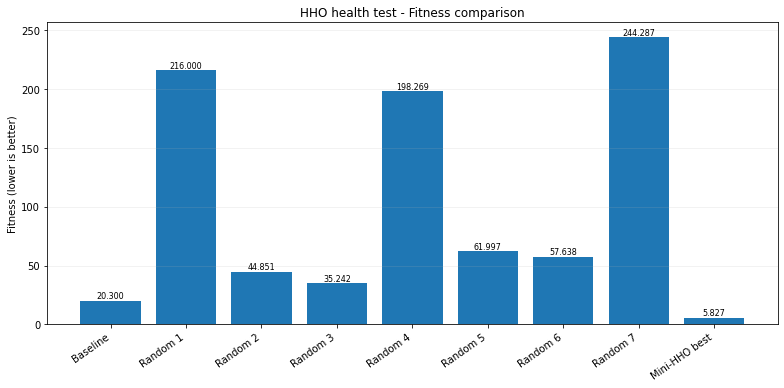

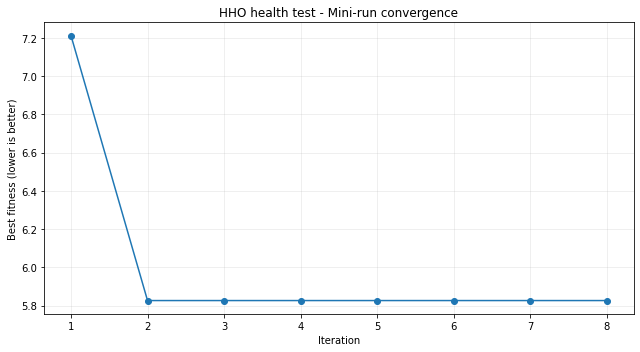

In [13]:
# =====================================================================
# HHO HEALTH TESTS
# =====================================================================
# These tests verify the HHO search space, fitness function, encoding,
# decoding, and a short mini-run before the expensive Smoke/Full stages.

import matplotlib.pyplot as plt

HEALTH_SEED = 909
HEALTH_SAMPLE_N = min(400, len(X_red_np))
health_rng = np.random.default_rng(HEALTH_SEED)
health_idx = health_rng.choice(len(X_red_np), size=HEALTH_SAMPLE_N, replace=False)
X_health = np.asarray(X_red_np)[health_idx]

health_eps_bounds = build_eps_bounds(
    X_health,
    minpts_list=MINPTS_LIST,
    q_low=0.02,
    q_high=0.98,
    expand_lo=0.65,
    expand_hi=1.80,
    seed=HEALTH_SEED,
)

health_baseline = repair_baseline_params_for_sample(
    X_health,
    BASELINE_PARAMS,
    health_eps_bounds,
    min_core=40,
)

health_fitness_base, health_baseline_info = make_fitness_soft_tradeoff(
    Xfit=X_health,
    eps_bounds_by_minpts=health_eps_bounds,
    baseline_params=health_baseline,
    w_sil=W_SIL,
    w_dbi=W_DBI,
    w_ch=W_CH,
    min_core=40,
)
health_fitness = wrap_fitness_pathB(
    health_fitness_base,
    X_health,
    health_eps_bounds,
)

health_LB, health_UB = make_LBUB_from_eps_bounds(health_eps_bounds)
assert np.all(np.isfinite(health_LB))
assert np.all(np.isfinite(health_UB))
assert np.all(health_UB > health_LB)

k0_h, eps0_h, minPts0_h, nAgg0_h = health_baseline
health_baseline_vec = encode_solution(
    k0_h, eps0_h, minPts0_h, nAgg0_h, health_eps_bounds
)
roundtrip = decode_solution(health_baseline_vec, health_eps_bounds)
assert roundtrip[0] == int(k0_h)
assert roundtrip[2] == int(minPts0_h)
assert roundtrip[3] == int(nAgg0_h)
assert np.isclose(roundtrip[1], float(eps0_h), rtol=0, atol=1e-10)

candidate_names = ['Baseline']
candidate_vectors = [health_baseline_vec]

for i in range(1, 8):
    candidate_names.append(f'Random {i}')
    candidate_vectors.append(
        health_LB + health_rng.random(4) * (health_UB - health_LB)
    )

candidate_fitness = np.array(
    [float(health_fitness(v)) for v in candidate_vectors],
    dtype=float,
)
assert np.all(np.isfinite(candidate_fitness))

# Short mini-HHO sanity run.
health_mini = run_hho_once(
    fobj=health_fitness,
    dim=4,
    pop_size=10,
    max_iter=8,
    seed=HEALTH_SEED,
    LB=health_LB,
    UB=health_UB,
    init_center=health_baseline_vec,
    **HHO_DEFAULTS,
)

health_trace = np.asarray(health_mini['trace'], dtype=float)
assert health_trace.shape == (8,)
assert np.all(np.isfinite(health_trace))
assert np.all(np.diff(health_trace) <= 1e-12)

candidate_names.append('Mini-HHO best')
candidate_fitness = np.append(candidate_fitness, health_mini['best_fit'])

health_test_df = pd.DataFrame({
    'Candidate': candidate_names,
    'Fitness': candidate_fitness,
})
print('HHO health-test baseline parameters:', health_baseline)
print('HHO health-test baseline info:', health_baseline_info)
print(health_test_df)
print('All HHO health tests passed.')

# Fitness bar chart requested for the HHO health-test stage.
plt.figure(figsize=(11, 5.5))
bars = plt.bar(health_test_df['Candidate'], health_test_df['Fitness'])
plt.ylabel('Fitness (lower is better)')
plt.title('HHO health test - Fitness comparison')
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', alpha=0.20)
for bar, value in zip(bars, health_test_df['Fitness']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:.3f}',
        ha='center',
        va='bottom',
        fontsize=8,
    )
plt.tight_layout()
plt.show()

# Mini-run convergence chart.
plt.figure(figsize=(9, 5))
plt.plot(np.arange(1, len(health_trace) + 1), health_trace, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Best fitness (lower is better)')
plt.title('HHO health test - Mini-run convergence')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Block 13: HHO Smoke Run — print all 60 iterations and draw all stage plots



SMOKE | START 1/20 | seed=1 | sample_n=400 | pop=50 | iterations=60
SMOKE | start 01/20 | seed=001 | iteration 001/060 | best_fitness=7.90720781
SMOKE | start 01/20 | seed=001 | iteration 002/060 | best_fitness=5.80615281
SMOKE | start 01/20 | seed=001 | iteration 003/060 | best_fitness=5.80615281
SMOKE | start 01/20 | seed=001 | iteration 004/060 | best_fitness=5.80615281
SMOKE | start 01/20 | seed=001 | iteration 005/060 | best_fitness=5.80615281
SMOKE | start 01/20 | seed=001 | iteration 006/060 | best_fitness=5.80615281
SMOKE | start 01/20 | seed=001 | iteration 007/060 | best_fitness=5.80615281
SMOKE | start 01/20 | seed=001 | iteration 008/060 | best_fitness=5.80615281
SMOKE | start 01/20 | seed=001 | iteration 009/060 | best_fitness=5.80615281
SMOKE | start 01/20 | seed=001 | iteration 010/060 | best_fitness=5.80615281
SMOKE | start 01/20 | seed=001 | iteration 011/060 | best_fitness=5.80615281
SMOKE | start 01/20 | seed=001 | iteration 012/060 | best_fitness=5.80615281
SMOKE |

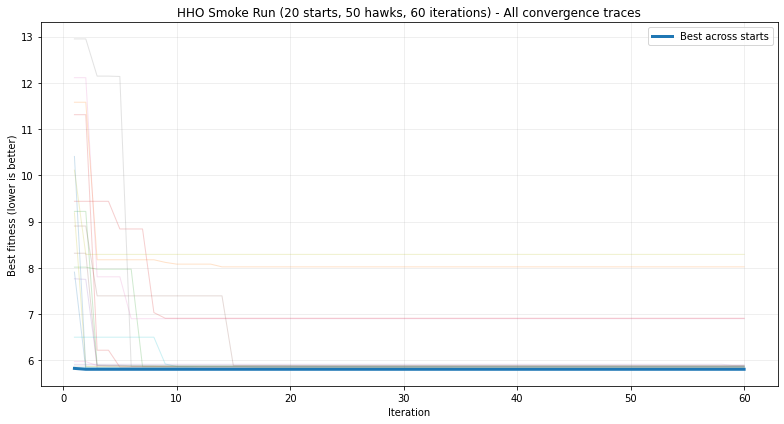

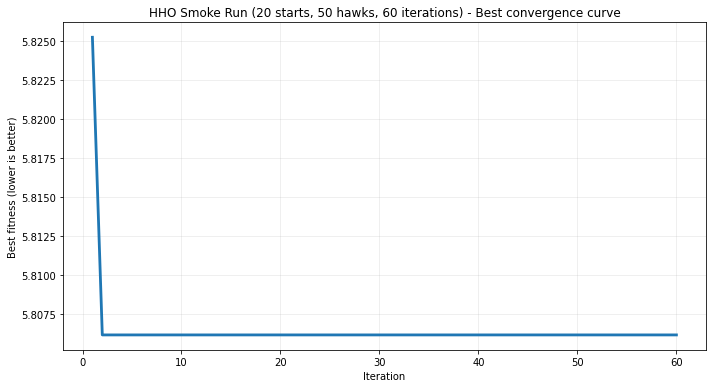

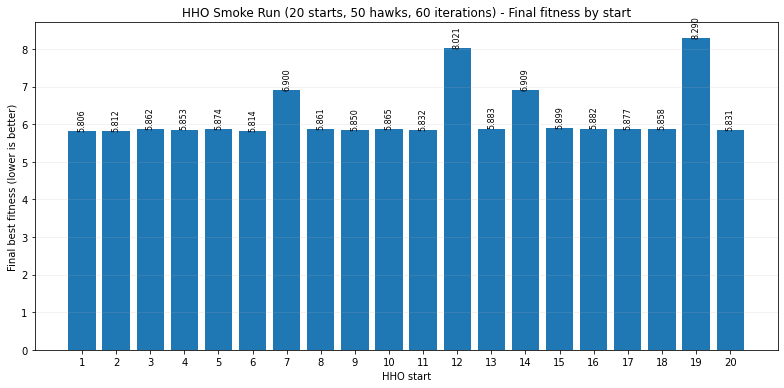

    Start  Seed  FinalFitness
0       1     1      5.806153
1       2     2      5.812322
2       3     3      5.861676
3       4     4      5.853467
4       5     5      5.874362
5       6     6      5.813670
6       7     7      6.899938
7       8     8      5.861263
8       9     9      5.850098
9      10    10      5.865481
10     11    11      5.832176
11     12    12      8.021145
12     13    13      5.883088
13     14    14      6.909318
14     15    15      5.899175
15     16    16      5.882134
16     17    17      5.877351
17     18    18      5.857913
18     19    19      8.290403
19     20    20      5.830784


In [14]:
# =====================================================================
# HHO SMOKE RUN
# 20 independent starts | 50 hawks | 60 iterations | sample_n=400
# Every one of the 60 iterations is printed for every start.
# =====================================================================

SMOKE_CFG = {
    'sample_n': 400,
    'n_starts': 20,
    'base_seed': 1,
    'pop_size': 50,
    'max_iter': 60,
}

smoke_best = hho_multistart(
    X_full=X_red_np,
    baseline_params=BASELINE_PARAMS,
    **SMOKE_CFG,
    print_all_iterations=True,
    stage_name='SMOKE',
)

print('\n' + '=' * 72)
print('SMOKE RUN FINISHED')
print('=' * 72)
print('Best fitness:', smoke_best['best_fit'])
print('Best seed:', smoke_best['seed'])
print('Number of starts:', len(smoke_best['runs']))
print('Elapsed seconds:', smoke_best['elapsed_sec'])

smoke_start_summary = plot_hho_stage(
    smoke_best,
    'HHO Smoke Run (20 starts, 50 hawks, 60 iterations)',
)
print(smoke_start_summary)


## Block 14: HHO Full Run — print all 160 iterations, draw all stage plots, and evaluate on full data



FULL | START 1/30 | seed=1 | sample_n=400 | pop=80 | iterations=160
FULL | start 01/30 | seed=001 | iteration 001/160 | best_fitness=5.81980594
FULL | start 01/30 | seed=001 | iteration 002/160 | best_fitness=5.81980594
FULL | start 01/30 | seed=001 | iteration 003/160 | best_fitness=5.81637002
FULL | start 01/30 | seed=001 | iteration 004/160 | best_fitness=5.81637002
FULL | start 01/30 | seed=001 | iteration 005/160 | best_fitness=5.81637002
FULL | start 01/30 | seed=001 | iteration 006/160 | best_fitness=5.80695017
FULL | start 01/30 | seed=001 | iteration 007/160 | best_fitness=5.80695017
FULL | start 01/30 | seed=001 | iteration 008/160 | best_fitness=5.80695017
FULL | start 01/30 | seed=001 | iteration 009/160 | best_fitness=5.80695017
FULL | start 01/30 | seed=001 | iteration 010/160 | best_fitness=5.80695017
FULL | start 01/30 | seed=001 | iteration 011/160 | best_fitness=5.80695017
FULL | start 01/30 | seed=001 | iteration 012/160 | best_fitness=5.80695017
FULL | start 01/30 

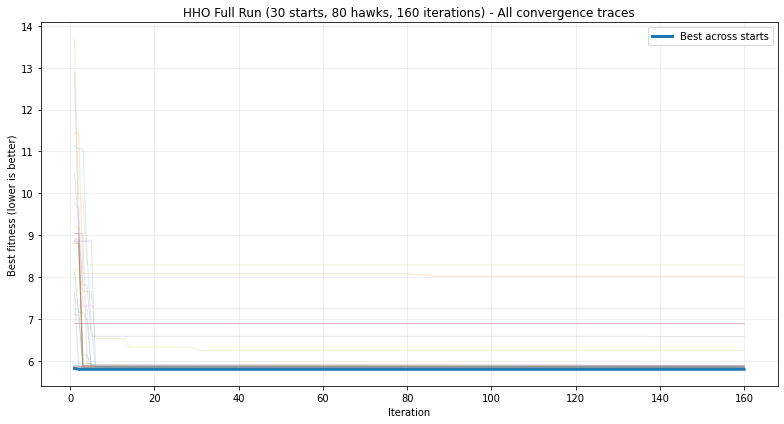

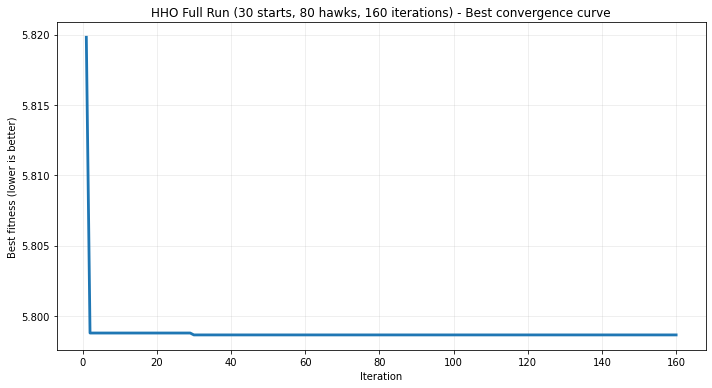

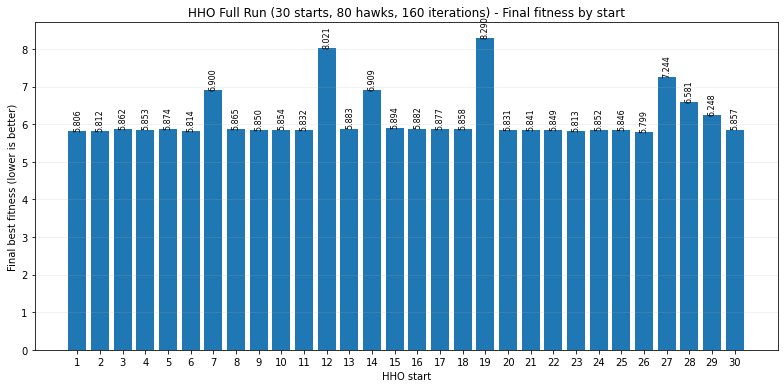

    Start  Seed  FinalFitness
0       1     1      5.806153
1       2     2      5.812401
2       3     3      5.861676
3       4     4      5.853467
4       5     5      5.874362
5       6     6      5.813670
6       7     7      6.899938
7       8     8      5.864607
8       9     9      5.850064
9      10    10      5.854053
10     11    11      5.832176
11     12    12      8.021145
12     13    13      5.883088
13     14    14      6.909318
14     15    15      5.894198
15     16    16      5.882134
16     17    17      5.877197
17     18    18      5.857913
18     19    19      8.290403
19     20    20      5.830784
20     21    21      5.840931
21     22    22      5.849332
22     23    23      5.812882
23     24    24      5.851702
24     25    25      5.846454
25     26    26      5.798648
26     27    27      7.244200
27     28    28      6.581127
28     29    29      6.248051
29     30    30      5.857304

FINAL HHO PARAMETERS ON FULL DATA
KMeans K: 6
Agglomerative K: 6
DBSC

In [15]:
# =====================================================================
# HHO FULL RUN
# 30 independent starts | 80 hawks | 160 iterations | sample_n=400
# Every one of the 160 iterations is printed for every start.
# =====================================================================

FULL_CFG = {
    'sample_n': 400,
    'n_starts': 30,
    'base_seed': 1,
    'pop_size': 80,
    'max_iter': 160,
}

full_best = hho_multistart(
    X_full=X_red_np,
    baseline_params=BASELINE_PARAMS,
    **FULL_CFG,
    print_all_iterations=True,
    stage_name='FULL',
)

print('\n' + '=' * 72)
print('FULL RUN FINISHED')
print('=' * 72)
print('Best fitness:', full_best['best_fit'])
print('Best seed:', full_best['seed'])
print('Number of starts:', len(full_best['runs']))
print('Elapsed seconds:', full_best['elapsed_sec'])

full_start_summary = plot_hho_stage(
    full_best,
    'HHO Full Run (30 starts, 80 hawks, 160 iterations)',
)
print(full_start_summary)

# The final thesis optimization result comes from the Full Run.
best = full_best

# Rebuild data-driven eps bounds on all customers before final evaluation.
eps_bounds_full = build_eps_bounds(
    X_red_np,
    minpts_list=MINPTS_LIST,
    q_low=0.02,
    q_high=0.98,
    expand_lo=0.65,
    expand_hi=1.80,
    seed=int(best['seed']),
)

full_report = evaluate_solution_on_full(
    X_red_np,
    best['best_sol'],
    eps_bounds_full,
    min_core=40,
)

opt_k = int(full_report['opt_k'])
opt_eps = float(full_report['opt_eps'])
opt_minPts = int(full_report['opt_minPts'])
opt_nAgg = int(full_report['opt_nAgg'])

print('\n' + '=' * 72)
print('FINAL HHO PARAMETERS ON FULL DATA')
print('=' * 72)
print('KMeans K:', opt_k)
print('Agglomerative K:', opt_nAgg)
print('DBSCAN eps:', round(opt_eps, 6))
print('DBSCAN min_samples:', opt_minPts)
print('Full-data KMeans metrics:', full_report['KMeans'])
print('Full-data Agglomerative metrics:', full_report['Agglo'])
print('Full-data DBSCAN metrics:', full_report['DBSCAN'])
print('Full-data DBSCAN diagnostics:', full_report['DBSCAN_diag'])


## Block 15: Build HHO-optimized base partitions and pairwise agreement


In [16]:
kmeans_labels_HHO = KMeans(
    n_clusters=opt_k,
    n_init=30,
    max_iter=500,
    random_state=RNG_SEED,
).fit_predict(X_red_np)

agglo_labels_HHO = AgglomerativeClustering(
    n_clusters=opt_nAgg,
    linkage="ward",
).fit_predict(X_red_np)

dbscan_labels_HHO_raw = DBSCAN(
    eps=opt_eps,
    min_samples=opt_minPts,
).fit_predict(X_red_np)

print("Pairwise ARI:")
print("  KMeans vs Agglo :", adjusted_rand_score(kmeans_labels_HHO, agglo_labels_HHO))
print("  KMeans vs DBSCAN:", adjusted_rand_score(kmeans_labels_HHO, dbscan_labels_HHO_raw))
print("  Agglo vs DBSCAN :", adjusted_rand_score(agglo_labels_HHO, dbscan_labels_HHO_raw))

print("Pairwise NMI:")
print("  KMeans vs Agglo :", normalized_mutual_info_score(kmeans_labels_HHO, agglo_labels_HHO))
print("  KMeans vs DBSCAN:", normalized_mutual_info_score(kmeans_labels_HHO, dbscan_labels_HHO_raw))
print("  Agglo vs DBSCAN :", normalized_mutual_info_score(agglo_labels_HHO, dbscan_labels_HHO_raw))


Pairwise ARI:
  KMeans vs Agglo : 1.0
  KMeans vs DBSCAN: 1.0
  Agglo vs DBSCAN : 1.0
Pairwise NMI:
  KMeans vs Agglo : 1.0
  KMeans vs DBSCAN: 0.9999999999999999
  Agglo vs DBSCAN : 0.9999999999999999


## Block 16: Weighted Ensemble Clustering — learn softmax weights on 1,200 samples


Ensemble-weight HHO | iteration 01/20 | best_fitness=0.28451938
Ensemble-weight HHO | iteration 02/20 | best_fitness=0.28451938
Ensemble-weight HHO | iteration 03/20 | best_fitness=0.28451938
Ensemble-weight HHO | iteration 04/20 | best_fitness=0.28451938
Ensemble-weight HHO | iteration 05/20 | best_fitness=0.28451938
Ensemble-weight HHO | iteration 06/20 | best_fitness=0.28451938
Ensemble-weight HHO | iteration 07/20 | best_fitness=0.28451938
Ensemble-weight HHO | iteration 08/20 | best_fitness=0.28451938
Ensemble-weight HHO | iteration 09/20 | best_fitness=0.28451938
Ensemble-weight HHO | iteration 10/20 | best_fitness=0.28451938
Ensemble-weight HHO | iteration 11/20 | best_fitness=0.28451938
Ensemble-weight HHO | iteration 12/20 | best_fitness=0.28451938
Ensemble-weight HHO | iteration 13/20 | best_fitness=0.28451938
Ensemble-weight HHO | iteration 14/20 | best_fitness=0.28451938
Ensemble-weight HHO | iteration 15/20 | best_fitness=0.28451938
Ensemble-weight HHO | iteration 16/20 | 

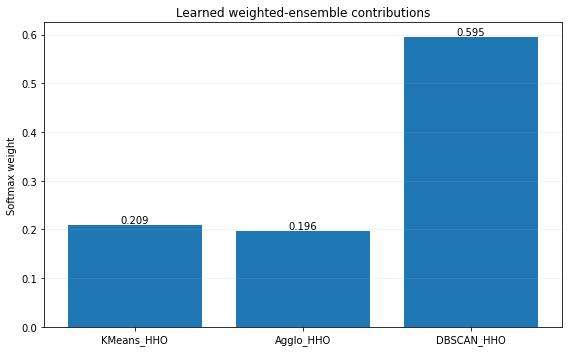

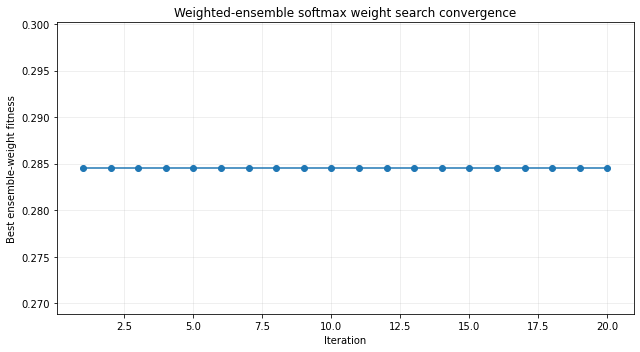

In [17]:
def fix_dbscan_noise_for_coassoc(labels):
    """Give each DBSCAN noise point a unique temporary label for co-association."""
    labels = np.asarray(labels).copy()
    noise = labels < 0
    if noise.any():
        max_label = labels[~noise].max() if (~noise).any() else -1
        labels[noise] = max_label + 1 + np.arange(int(noise.sum()))
    return labels


def sanitize_dist_matrix(D):
    D = np.asarray(D, dtype=np.float64)
    D = np.nan_to_num(D, nan=0.0, posinf=1.0, neginf=0.0)
    D = 0.5 * (D + D.T)
    np.fill_diagonal(D, 0.0)
    return np.clip(D, 0.0, 1.0)


def sanitize_coassoc(C):
    C = np.asarray(C, dtype=np.float64)
    C = np.nan_to_num(C, nan=0.0, posinf=1.0, neginf=0.0)
    C = 0.5 * (C + C.T)
    np.fill_diagonal(C, 1.0)
    return np.clip(C, 0.0, 1.0)


dbscan_labels_HHO_fixed = fix_dbscan_noise_for_coassoc(dbscan_labels_HHO_raw)

base_partitions_for_ens = [
    ("KMeans_HHO", kmeans_labels_HHO),
    ("Agglo_HHO", agglo_labels_HHO),
    ("DBSCAN_HHO", dbscan_labels_HHO_fixed),
]

P = len(base_partitions_for_ens)
WEIGHT_SAMPLE_N = 1200

if len(X_red_np) <= WEIGHT_SAMPLE_N:
    w_idx = np.arange(len(X_red_np))
else:
    w_idx = rng.choice(len(X_red_np), size=WEIGHT_SAMPLE_N, replace=False)

Xw = X_red_np[w_idx]
m = len(w_idx)

# Use subset silhouette as the base-partition quality signal.
base_quality = []
for name, labels_full in base_partitions_for_ens:
    labels_sub = dbscan_labels_HHO_raw[w_idx] if name == "DBSCAN_HHO" else np.asarray(labels_full)[w_idx]
    base_quality.append(safe_silhouette(Xw, labels_sub, on_core_if_noise=True))

base_quality = np.asarray(base_quality, dtype=float)
q_min, q_max = float(base_quality.min()), float(base_quality.max())
if not np.isfinite(q_max - q_min) or q_max - q_min < 1e-8:
    q_norm = np.ones_like(base_quality)
else:
    q_norm = (base_quality - q_min) / (q_max - q_min)


def weighted_coassoc_subset(weights):
    C = np.zeros((m, m), dtype=np.float64)
    for j, (_, labels_full) in enumerate(base_partitions_for_ens):
        labels = np.asarray(labels_full)[w_idx]
        C += float(weights[j]) * (labels[:, None] == labels[None, :]).astype(np.float64)
    np.fill_diagonal(C, 1.0)
    return np.clip(C, 0.0, 1.0)


def best_consensus_on_subset(coassoc, k_scan=range(2, 13)):
    D = sanitize_dist_matrix(1.0 - coassoc)
    Z = linkage(squareform(D, checks=False), method="average")

    best_k, best_sil, best_labels = None, -np.inf, None
    for K in k_scan:
        labels = fcluster(Z, t=int(K), criterion="maxclust").astype(int)
        if len(np.unique(labels)) < 2:
            continue
        try:
            sil = float(silhouette_score(Xw, labels))
        except Exception:
            continue
        if sil > best_sil:
            best_k, best_sil, best_labels = int(K), sil, labels

    return best_k, best_sil, best_labels


def fitness_weights(raw_weights):
    """Optimize unconstrained logits; softmax converts them to valid ensemble weights."""
    raw_weights = np.asarray(raw_weights, dtype=float).ravel()
    if raw_weights.size != P:
        return 10.0

    weights = np.exp(raw_weights - np.max(raw_weights))
    weights = weights / (weights.sum() + 1e-12)

    coassoc = weighted_coassoc_subset(weights)
    _, sil_best, labels_best = best_consensus_on_subset(coassoc)
    if labels_best is None or not np.isfinite(sil_best):
        return 10.0

    weak_penalty = float(np.sum(weights * (1.0 - q_norm)))
    return float((1.0 - sil_best) + 0.25 * weak_penalty)


# Small HHO-like search for the three ensemble logits.
popSize_w = 12
maxIter_w = 20
lb_w = -2.0 * np.ones(P, dtype=float)
ub_w = 2.0 * np.ones(P, dtype=float)

Xpop = lb_w + rng.random((popSize_w, P)) * (ub_w - lb_w)
fit_w = np.array([fitness_weights(Xpop[i]) for i in range(popSize_w)], dtype=float)

bestIdx_w = int(np.argmin(fit_w))
bestFit_w = float(fit_w[bestIdx_w])
bestSol_w = Xpop[bestIdx_w].copy()
E0_w = 2.0 * rng.random(popSize_w) - 1.0

weight_trace = []

for t in range(1, maxIter_w + 1):
    for i in range(popSize_w):
        E = 2.0 * E0_w[i] * (1.0 - t / maxIter_w)

        if abs(E) >= 1.0:
            rndIdx = int(rng.integers(0, popSize_w))
            Xnew = Xpop[rndIdx] - rng.random(P) * np.abs(
                Xpop[rndIdx] - 2.0 * rng.random(P) * Xpop[i]
            )
        else:
            if rng.random() < 0.5:
                Xnew = bestSol_w - E * np.abs(bestSol_w - Xpop[i])
            else:
                Xnew = bestSol_w + rng.random(P) * np.abs(bestSol_w - Xpop[i])

        Xnew = np.clip(Xnew, lb_w, ub_w)
        fnew = float(fitness_weights(Xnew))

        if fnew < fit_w[i]:
            Xpop[i] = Xnew
            fit_w[i] = fnew
            if fnew < bestFit_w:
                bestFit_w = fnew
                bestSol_w = Xnew.copy()


    weight_trace.append(bestFit_w)
    print(f'Ensemble-weight HHO | iteration {t:02d}/{maxIter_w:02d} | best_fitness={bestFit_w:.8f}')

weights_exp = np.exp(bestSol_w - np.max(bestSol_w))
opt_w = weights_exp / (weights_exp.sum() + 1e-12)

print("Final softmax ensemble weights:")
for (name, _), weight in zip(base_partitions_for_ens, opt_w):
    print(f"  {name:12s}: {float(weight):.6f}")


# Visualize learned ensemble weights.
import matplotlib.pyplot as plt
ensemble_weight_df = pd.DataFrame({
    'Algorithm': [name for name, _ in base_partitions_for_ens],
    'Weight': opt_w,
})

plt.figure(figsize=(8, 5))
bars = plt.bar(ensemble_weight_df['Algorithm'], ensemble_weight_df['Weight'])
plt.ylabel('Softmax weight')
plt.title('Learned weighted-ensemble contributions')
plt.grid(axis='y', alpha=0.20)
for bar, value in zip(bars, ensemble_weight_df['Weight']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:.3f}',
        ha='center',
        va='bottom',
    )
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(np.arange(1, len(weight_trace) + 1), weight_trace, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Best ensemble-weight fitness')
plt.title('Weighted-ensemble softmax weight search convergence')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Block 17: Final weighted co-association consensus and K scan


     K  Silhouette        DBI            CH
0    2    0.252390   1.048572    956.607415
1    3    0.384655   0.843194   1555.018646
2    4    0.533308   0.712693   3366.892719
3    5    0.669490   0.541146   6725.899698
4    6    0.711911   0.408060  11588.441693
5    7    0.663063   5.088505   9656.321394
6    8    0.598654   6.848830   8276.642581
7    9    0.595047   7.008051   7243.910438
8   10    0.593731  12.439442   6437.532580
9   11    0.462280  14.158335   5796.357125
10  12    0.461326  14.833555   5269.597567
FINAL ENSEMBLE | K=6 | Silhouette=0.711911 | DBI=0.408060 | CH=11588.44


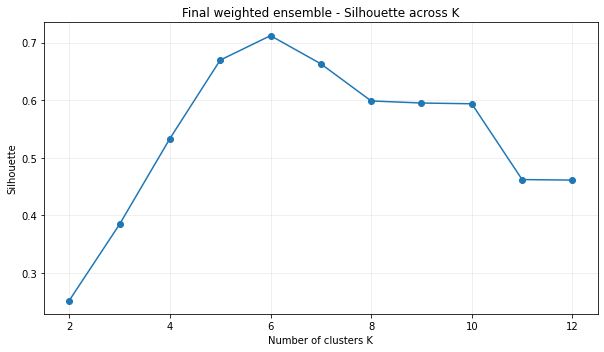

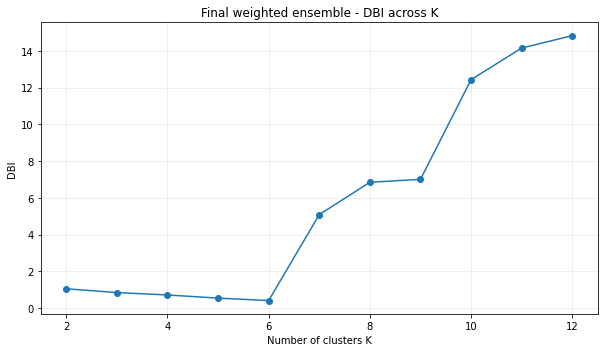

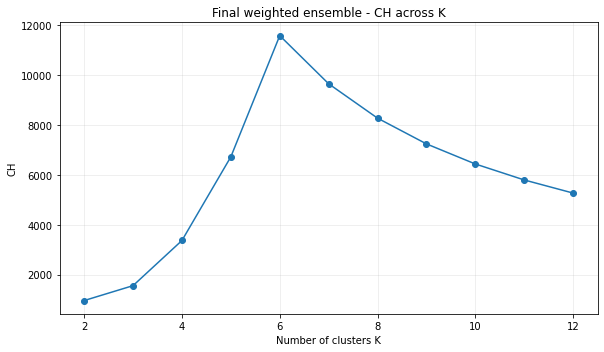

In [18]:
n = X_red_np.shape[0]
coassoc = np.zeros((n, n), dtype=np.float64)

for (_, labels), weight in zip(base_partitions_for_ens, opt_w):
    labels = np.asarray(labels)
    coassoc += float(weight) * (labels[:, None] == labels[None, :]).astype(np.float64)

coassoc = sanitize_coassoc(coassoc)
dist_full = sanitize_dist_matrix(1.0 - coassoc)

Y = squareform(dist_full, checks=False)

# Add a tiny deterministic jitter to break exact hierarchical-distance ties.
tie_rng = np.random.default_rng(RNG_SEED)
Y = np.clip(Y + tie_rng.normal(0.0, 1e-6, size=Y.shape), 0.0, 1.0)
Z_full = linkage(Y, method="average")

ensemble_rows = []
bestK_final = None
bestSil_final = -np.inf
ensemble_labels_final = None

for K in range(2, 13):
    labels = fcluster(Z_full, t=int(K), criterion="maxclust").astype(int)
    labels = labels - labels.min()

    if len(np.unique(labels)) < 2:
        continue

    sil = safe_silhouette(X_red_np, labels, on_core_if_noise=False)
    dbi = safe_dbi(X_red_np, labels, on_core_if_noise=False)
    ch = safe_ch(X_red_np, labels, on_core_if_noise=False)

    ensemble_rows.append({"K": K, "Silhouette": sil, "DBI": dbi, "CH": ch})

    if np.isfinite(sil) and sil > bestSil_final:
        bestSil_final = float(sil)
        bestK_final = int(K)
        ensemble_labels_final = labels.copy()

if ensemble_labels_final is None:
    raise RuntimeError("Final ensemble K scan did not produce a valid clustering.")

ens_results_df = pd.DataFrame(ensemble_rows)
final_sil = safe_silhouette(X_red_np, ensemble_labels_final, on_core_if_noise=False)
final_dbi = safe_dbi(X_red_np, ensemble_labels_final, on_core_if_noise=False)
final_ch = safe_ch(X_red_np, ensemble_labels_final, on_core_if_noise=False)

print(ens_results_df)
print(
    f"FINAL ENSEMBLE | K={bestK_final} | "
    f"Silhouette={final_sil:.6f} | DBI={final_dbi:.6f} | CH={final_ch:.2f}"
)


# K-scan diagnostic plots for the final weighted ensemble.
import matplotlib.pyplot as plt

for metric_name in ['Silhouette', 'DBI', 'CH']:
    plt.figure(figsize=(8.5, 5))
    plt.plot(ens_results_df['K'], ens_results_df[metric_name], marker='o')
    plt.xlabel('Number of clusters K')
    plt.ylabel(metric_name)
    plt.title(f'Final weighted ensemble - {metric_name} across K')
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## Block 18: Final output table, metrics summary, and cluster profiling


In [19]:
out = work_pp.copy()
out["Label_KMeans_HHO"] = kmeans_labels_HHO
out["Label_Agglo_HHO"] = agglo_labels_HHO
out["Label_DBSCAN_HHO"] = dbscan_labels_HHO_raw
out["Label_Ensemble_FINAL"] = ensemble_labels_final

labels_dict = {
    "KMeans (HHO)": kmeans_labels_HHO,
    "Agglo (HHO)": agglo_labels_HHO,
    "DBSCAN (HHO)": dbscan_labels_HHO_raw,
    "Ensemble FINAL": ensemble_labels_final,
    "KMeans (Baseline)": kmeans_labels,
    "Agglo (Baseline)": agglo_labels,
    "DBSCAN (Baseline)": dbscan_labels,
}
if spectral_labels is not None:
    labels_dict["Spectral (Baseline)"] = spectral_labels

summary_rows = []
for name, labels in labels_dict.items():
    labels = np.asarray(labels)
    md = metrics_dict(X_red_np, labels, min_core=max(10, int(0.02 * len(X_red_np))))
    summary_rows.append({
        "Method": name,
        "Sil_core": md["sil_core"],
        "DBI_core": md["dbi_core"],
        "CH_core": md["ch_core"],
        "Sil_pen": md["sil_pen"],
        "DBI_pen": md["dbi_pen"],
        "n_clusters": md["n_clusters"],
        "noise_ratio": md["noise_ratio"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Sil_core", ascending=False).reset_index(drop=True)
print(summary_df)

# Profile the final ensemble clusters on the original preprocessed features.
prof_df = out.copy()
prof_df["Cluster"] = ensemble_labels_final

cluster_sizes = (
    prof_df["Cluster"].value_counts().sort_index().rename("size").reset_index()
)
cluster_sizes.columns = ["Cluster", "size"]

profile_num_cols = [c for c in numeric_cols if c in prof_df.columns]
cluster_profile_num = prof_df.groupby("Cluster")[profile_num_cols].agg(["mean", "median", "count"])
cluster_profile_num.columns = [f"{c}_{stat}" for c, stat in cluster_profile_num.columns]
cluster_profile_num = cluster_profile_num.reset_index()

TOPK = 3

def topk_with_pct(series, k=3):
    vc = series.value_counts(dropna=True)
    total = float(vc.sum()) if vc.sum() else 1.0
    return [f"{idx} ({val / total * 100:.1f}%)" for idx, val in vc.head(k).items()]

profile_cat_rows = []
for cluster_id in sorted(prof_df["Cluster"].unique()):
    sub = prof_df[prof_df["Cluster"] == cluster_id]
    row = {"Cluster": int(cluster_id)}
    for c in categorical_cols:
        vals = topk_with_pct(sub[c].astype("string"), TOPK)
        row[f"{c}_Top{TOPK}"] = " | ".join(vals)
    profile_cat_rows.append(row)

cluster_profile_cat = pd.DataFrame(profile_cat_rows)

print("Cluster sizes:")
print(cluster_sizes)
print("Numeric profile:")
print(cluster_profile_num)
print("Categorical profile:")
print(cluster_profile_cat)


                Method  Sil_core  DBI_core       CH_core   Sil_pen   DBI_pen  \
0         KMeans (HHO)  0.711911  0.408060  11588.441693  0.711911  0.408060   
1          Agglo (HHO)  0.711911  0.408060  11588.441693  0.711911  0.408060   
2         DBSCAN (HHO)  0.711911  0.408060  11588.441693  0.711911  0.408060   
3       Ensemble FINAL  0.711911  0.408060  11588.441693  0.711911  0.408060   
4    KMeans (Baseline)  0.711911  0.408060  11588.441693  0.711911  0.408060   
5     Agglo (Baseline)  0.711911  0.408060  11588.441693  0.711911  0.408060   
6    DBSCAN (Baseline)  0.692755  0.519916  10061.858425  0.690319  0.522449   
7  Spectral (Baseline)  0.082027  2.419403    477.240460  0.082027  2.419403   

   n_clusters  noise_ratio  
0           6     0.000000  
1           6     0.000000  
2           6     0.000000  
3           6     0.000000  
4           6     0.000000  
5           6     0.000000  
6           7     0.004872  
7           6     0.000000  
Cluster sizes:
   

## Block 19: Dedicated Multi-Run HHO — 20 independent starts



MULTI-RUN | START 1/20 | seed=101 | sample_n=400 | pop=50 | iterations=60
MULTI-RUN completed start 1/20 | seed=101 | final_best_fitness=6.72872355

MULTI-RUN | START 2/20 | seed=102 | sample_n=400 | pop=50 | iterations=60
MULTI-RUN completed start 2/20 | seed=102 | final_best_fitness=7.61687101

MULTI-RUN | START 3/20 | seed=103 | sample_n=400 | pop=50 | iterations=60
MULTI-RUN completed start 3/20 | seed=103 | final_best_fitness=5.83451645

MULTI-RUN | START 4/20 | seed=104 | sample_n=400 | pop=50 | iterations=60
MULTI-RUN completed start 4/20 | seed=104 | final_best_fitness=5.91755382

MULTI-RUN | START 5/20 | seed=105 | sample_n=400 | pop=50 | iterations=60
MULTI-RUN completed start 5/20 | seed=105 | final_best_fitness=8.03918914

MULTI-RUN | START 6/20 | seed=106 | sample_n=400 | pop=50 | iterations=60
MULTI-RUN completed start 6/20 | seed=106 | final_best_fitness=5.83734496

MULTI-RUN | START 7/20 | seed=107 | sample_n=400 | pop=50 | iterations=60
MULTI-RUN completed start 7/20 

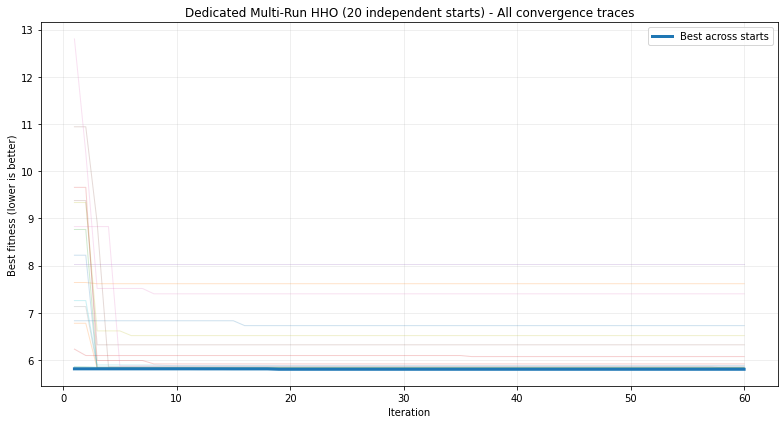

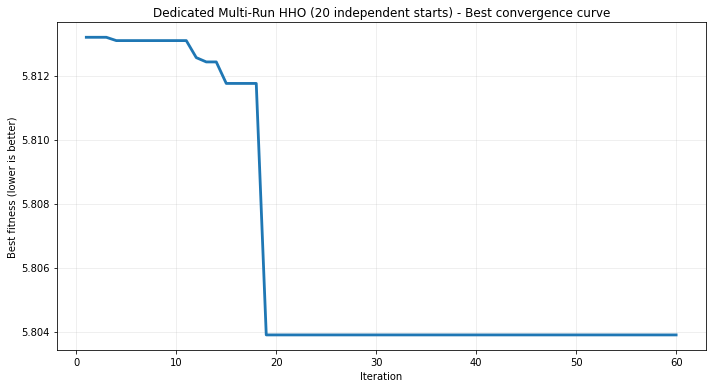

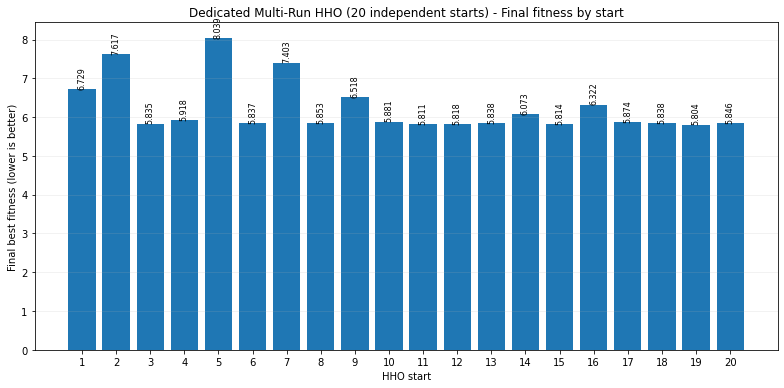

    Start  Seed  FinalFitness
0       1   101      6.728724
1       2   102      7.616871
2       3   103      5.834516
3       4   104      5.917554
4       5   105      8.039189
5       6   106      5.837345
6       7   107      7.402558
7       8   108      5.853057
8       9   109      6.517694
9      10   110      5.881355
10     11   111      5.810765
11     12   112      5.818363
12     13   113      5.838295
13     14   114      6.073031
14     15   115      5.813959
15     16   116      6.322334
16     17   117      5.873646
17     18   118      5.838338
18     19   119      5.803893
19     20   120      5.846285


In [20]:
# =====================================================================
# DEDICATED MULTI-RUN HHO
# 20 independent HHO starts used only for the stability ensemble.
# Seeds 101..120 are deliberately separate from the Smoke/Full seeds.
# =====================================================================

MULTIRUN_CFG = {
    'sample_n': 400,
    'n_starts': 20,
    'base_seed': 101,
    'pop_size': 50,
    'max_iter': 60,
}

multirun_hho = hho_multistart(
    X_full=X_red_np,
    baseline_params=BASELINE_PARAMS,
    **MULTIRUN_CFG,
    print_all_iterations=False,
    stage_name='MULTI-RUN',
)

print('\n' + '=' * 72)
print('DEDICATED MULTI-RUN HHO FINISHED')
print('=' * 72)
print('Number of independent starts:', len(multirun_hho['runs']))
print('Seeds:', [r['seed'] for r in multirun_hho['runs']])
print('Best multi-run fitness:', multirun_hho['best_fit'])
print('Best multi-run seed:', multirun_hho['seed'])

multirun_start_summary = plot_hho_stage(
    multirun_hho,
    'Dedicated Multi-Run HHO (20 independent starts)',
)
print(multirun_start_summary)


## Block 20: Multi-Run HHO + Ensemble — 60 partitions, quality/stability weighting, and consensus


Multi-run algorithm-level weights:
    algorithm    weight
0   Agglo_HHO  0.342031
1  KMeans_HHO  0.342031
2  DBSCAN_HHO  0.315937
     K  Silhouette       DBI            CH
0    2    0.404381  1.059112   1438.212359
1    3    0.358500  0.701771    972.847631
2    4    0.524821  0.767756   2625.652701
3    5    0.573607  0.569498   3558.317662
4    6    0.711911  0.408060  11588.441693
5    7    0.639121  0.441975   9663.394548
6    8    0.616198  0.454943   8290.924608
7    9    0.551688  2.535185   7254.382345
8   10    0.524657  7.762343   6447.236847
9   11    0.521050  7.809568   5803.998515
10  12    0.520502  8.846901   5275.427270
MULTI-RUN FINAL | K=6 | Silhouette=0.711911 | DBI=0.408060 | CH=11588.44
ARI(main ensemble, multi-run consensus) = 1.0
NMI(main ensemble, multi-run consensus) = 1.0


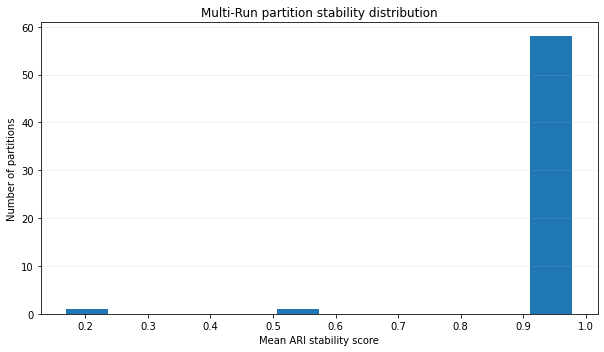

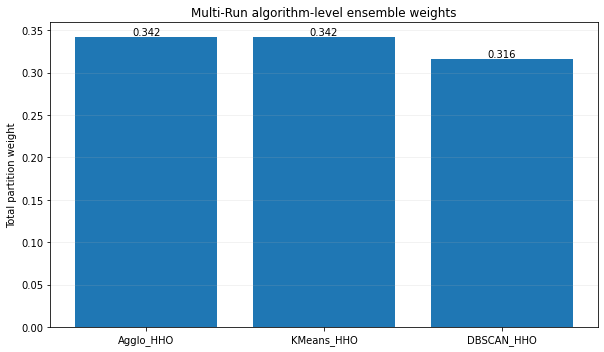

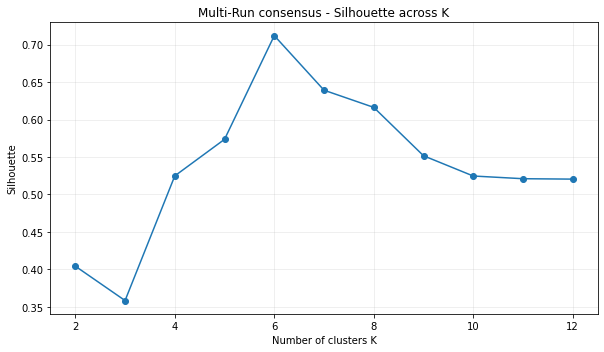

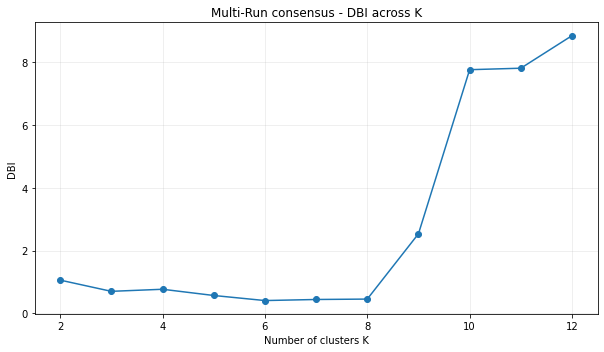

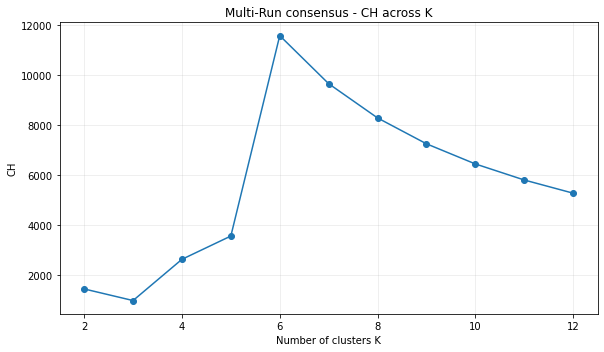

In [21]:
# Each independent Multi-Run HHO start contributes three full-data partitions.
MR_X = X_red_np
MR_runs = multirun_hho['runs']
MR_seed_global = RNG_SEED


def MR_fix_dbscan_noise(labels):
    labels = np.asarray(labels).copy()
    noise = labels < 0
    if noise.any():
        max_label = labels[~noise].max() if (~noise).any() else -1
        labels[noise] = max_label + 1 + np.arange(int(noise.sum()))
    return labels


def MR_safe_metrics(X, labels):
    labels = np.asarray(labels)
    if np.any(labels == -1):
        mask = labels >= 0
        if mask.sum() < 10 or len(np.unique(labels[mask])) < 2:
            return np.nan, np.nan, np.nan
        X_use, y_use = X[mask], labels[mask]
    else:
        if len(np.unique(labels)) < 2:
            return np.nan, np.nan, np.nan
        X_use, y_use = X, labels

    try:
        sil = float(silhouette_score(X_use, y_use))
        dbi = float(davies_bouldin_score(X_use, y_use))
        ch = float(calinski_harabasz_score(X_use, y_use))
    except Exception:
        return np.nan, np.nan, np.nan

    return sil, dbi, ch


def MR_minmax_norm(values, higher_is_better=True):
    x = np.asarray(values, dtype=float)
    if not higher_is_better:
        x = -x

    finite = x[np.isfinite(x)]
    if finite.size == 0:
        return np.ones_like(x)

    worst = np.min(finite)
    x = np.where(np.isfinite(x), x, worst)
    lo, hi = float(np.min(x)), float(np.max(x))
    return np.ones_like(x) if hi - lo < 1e-12 else (x - lo) / (hi - lo)


MR_all_partition_records = []

for run_idx, run_rec in enumerate(MR_runs):
    run_bounds = run_rec["eps_bounds_by_minpts"]
    k, eps, minPts, nAgg = decode_solution(run_rec["best_sol"], run_bounds)
    run_seed = int(run_rec.get("seed", MR_seed_global))

    lab_k = KMeans(
        n_clusters=k,
        n_init=30,
        max_iter=500,
        random_state=run_seed,
    ).fit_predict(MR_X)

    lab_a = AgglomerativeClustering(
        n_clusters=nAgg,
        linkage="ward",
    ).fit_predict(MR_X)

    lab_d = DBSCAN(
        eps=round(float(eps), 6),
        min_samples=minPts,
    ).fit_predict(MR_X)

    for alg_name, labels_raw, labels_for_ens in [
        ("KMeans_HHO", lab_k, lab_k),
        ("Agglo_HHO", lab_a, lab_a),
        ("DBSCAN_HHO", lab_d, MR_fix_dbscan_noise(lab_d)),
    ]:
        sil, dbi, ch = MR_safe_metrics(MR_X, labels_raw)
        MR_all_partition_records.append({
            "run_idx": run_idx,
            "seed": run_seed,
            "algorithm": alg_name,
            "name": f"{alg_name}_run{run_idx}_seed{run_seed}",
            "k": k,
            "eps": eps,
            "minPts": minPts,
            "nAgg": nAgg,
            "n_clusters": int(len(set(labels_raw.tolist()) - {-1})),
            "noise_ratio": float(np.mean(labels_raw == -1)) if np.any(labels_raw == -1) else 0.0,
            "sil": sil,
            "dbi": dbi,
            "ch": ch,
            "labels_raw": np.asarray(labels_raw),
            "labels_for_ens": np.asarray(labels_for_ens),
        })

# Keep only valid, sufficiently clustered, low-noise partitions.
MR_valid_records = [
    rec for rec in MR_all_partition_records
    if np.isfinite(rec["sil"])
    and np.isfinite(rec["dbi"])
    and np.isfinite(rec["ch"])
    and rec["n_clusters"] >= 2
    and rec["noise_ratio"] <= 0.10
]

if len(MR_valid_records) < 3:
    raise RuntimeError("Fewer than three valid multi-run partitions remain after filtering.")

# If more than 60 partitions exist, first keep the 60 highest-quality partitions.
MR_valid_df = pd.DataFrame([
    {k: v for k, v in rec.items() if k not in ("labels_raw", "labels_for_ens")}
    for rec in MR_valid_records
])

sil_norm = MR_minmax_norm(MR_valid_df["sil"].to_numpy(), higher_is_better=True)
dbi_norm = MR_minmax_norm(MR_valid_df["dbi"].to_numpy(), higher_is_better=False)
ch_norm = MR_minmax_norm(np.log1p(MR_valid_df["ch"].to_numpy()), higher_is_better=True)
MR_valid_df["quality_score"] = 0.45 * sil_norm + 0.35 * dbi_norm + 0.20 * ch_norm

if len(MR_valid_df) > 60:
    keep_names = set(MR_valid_df.nlargest(60, "quality_score")["name"])
    MR_selected_records = [rec for rec in MR_valid_records if rec["name"] in keep_names]
else:
    MR_selected_records = MR_valid_records

MR_selected_partitions_df = pd.DataFrame([
    {k: v for k, v in rec.items() if k not in ("labels_raw", "labels_for_ens")}
    for rec in MR_selected_records
]).reset_index(drop=True)

# Recalculate normalized quality on the selected set.
sil_norm = MR_minmax_norm(MR_selected_partitions_df["sil"].to_numpy(), True)
dbi_norm = MR_minmax_norm(MR_selected_partitions_df["dbi"].to_numpy(), False)
ch_norm = MR_minmax_norm(np.log1p(MR_selected_partitions_df["ch"].to_numpy()), True)
MR_selected_partitions_df["quality_score"] = 0.45 * sil_norm + 0.35 * dbi_norm + 0.20 * ch_norm

# Stability of each partition = mean ARI against all other selected partitions.
MR_P = len(MR_selected_records)
MR_ari_matrix = np.eye(MR_P, dtype=float)

for i in range(MR_P):
    for j in range(i + 1, MR_P):
        ari = adjusted_rand_score(
            MR_selected_records[i]["labels_for_ens"],
            MR_selected_records[j]["labels_for_ens"],
        )
        MR_ari_matrix[i, j] = ari
        MR_ari_matrix[j, i] = ari

MR_stability_score = (
    (MR_ari_matrix.sum(axis=1) - 1.0) / (MR_P - 1)
    if MR_P > 1
    else np.ones(MR_P)
)
MR_stability_score = np.clip(MR_stability_score, 0.0, 1.0)
MR_selected_partitions_df["stability_score"] = MR_stability_score

# Final multi-run partition score: 70% quality + 30% stability.
MR_combined_score = (
    0.70 * MR_selected_partitions_df["quality_score"].to_numpy(dtype=float)
    + 0.30 * MR_selected_partitions_df["stability_score"].to_numpy(dtype=float)
)
MR_combined_score = np.maximum(MR_combined_score, 1e-6)
MR_partition_weights = MR_combined_score / MR_combined_score.sum()
MR_selected_partitions_df["weight"] = MR_partition_weights

MR_algorithm_weight_summary = (
    MR_selected_partitions_df.groupby("algorithm")["weight"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Build the multi-run weighted co-association matrix.
MR_n = len(MR_X)
MR_coassoc = np.zeros((MR_n, MR_n), dtype=np.float64)

for rec, weight in zip(MR_selected_records, MR_partition_weights):
    labels = np.asarray(rec["labels_for_ens"])
    for cluster_id in np.unique(labels):
        idx = np.where(labels == cluster_id)[0]
        if idx.size > 1:
            MR_coassoc[np.ix_(idx, idx)] += float(weight)

MR_coassoc = sanitize_coassoc(MR_coassoc)
MR_dist = sanitize_dist_matrix(1.0 - MR_coassoc)
MR_Y = squareform(MR_dist, checks=False)

MR_tie_rng = np.random.default_rng(RNG_SEED)
MR_Y = np.clip(MR_Y + MR_tie_rng.normal(0.0, 1e-7, size=MR_Y.shape), 0.0, 1.0)
MR_Z = linkage(MR_Y, method="average")

MR_rows = []
MR_bestK = None
MR_bestSil = -np.inf
MR_ensemble_labels = None

for K in range(2, 13):
    labels = fcluster(MR_Z, t=int(K), criterion="maxclust").astype(int)
    labels = labels - labels.min()

    if len(np.unique(labels)) < 2:
        continue

    sil = float(silhouette_score(MR_X, labels))
    dbi = float(davies_bouldin_score(MR_X, labels))
    ch = float(calinski_harabasz_score(MR_X, labels))

    MR_rows.append({"K": K, "Silhouette": sil, "DBI": dbi, "CH": ch})
    if sil > MR_bestSil:
        MR_bestSil = sil
        MR_bestK = K
        MR_ensemble_labels = labels.copy()

MR_results_df = pd.DataFrame(MR_rows)
MR_final_sil = float(silhouette_score(MR_X, MR_ensemble_labels))
MR_final_dbi = float(davies_bouldin_score(MR_X, MR_ensemble_labels))
MR_final_ch = float(calinski_harabasz_score(MR_X, MR_ensemble_labels))

# Compare the multi-run consensus with the main final ensemble.
MR_vs_main_ARI = adjusted_rand_score(ensemble_labels_final, MR_ensemble_labels)
MR_vs_main_NMI = normalized_mutual_info_score(ensemble_labels_final, MR_ensemble_labels)

print("Multi-run algorithm-level weights:")
print(MR_algorithm_weight_summary)
print(MR_results_df)
print(
    f"MULTI-RUN FINAL | K={MR_bestK} | Silhouette={MR_final_sil:.6f} | "
    f"DBI={MR_final_dbi:.6f} | CH={MR_final_ch:.2f}"
)
print("ARI(main ensemble, multi-run consensus) =", MR_vs_main_ARI)
print("NMI(main ensemble, multi-run consensus) =", MR_vs_main_NMI)


# Multi-run stability and algorithm-weight diagnostic plots.
import matplotlib.pyplot as plt

plt.figure(figsize=(8.5, 5))
plt.hist(MR_selected_partitions_df['stability_score'], bins=12)
plt.xlabel('Mean ARI stability score')
plt.ylabel('Number of partitions')
plt.title('Multi-Run partition stability distribution')
plt.grid(axis='y', alpha=0.20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8.5, 5))
bars = plt.bar(
    MR_algorithm_weight_summary['algorithm'],
    MR_algorithm_weight_summary['weight'],
)
plt.ylabel('Total partition weight')
plt.title('Multi-Run algorithm-level ensemble weights')
plt.grid(axis='y', alpha=0.20)
for bar, value in zip(bars, MR_algorithm_weight_summary['weight']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:.3f}',
        ha='center',
        va='bottom',
    )
plt.tight_layout()
plt.show()

for metric_name in ['Silhouette', 'DBI', 'CH']:
    plt.figure(figsize=(8.5, 5))
    plt.plot(MR_results_df['K'], MR_results_df[metric_name], marker='o')
    plt.xlabel('Number of clusters K')
    plt.ylabel(metric_name)
    plt.title(f'Multi-Run consensus - {metric_name} across K')
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## Block 21: Final visualization of all customers


Number of customers visualized: 3900
Final number of clusters: 6


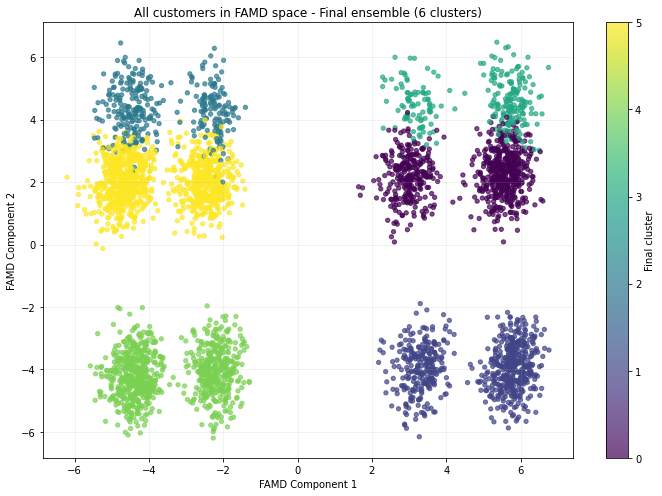

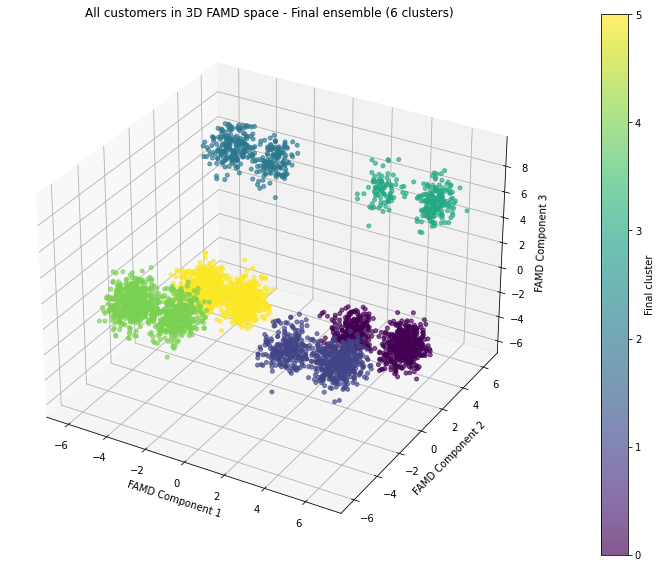

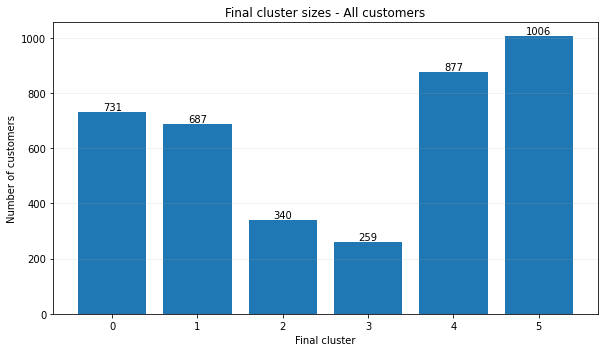

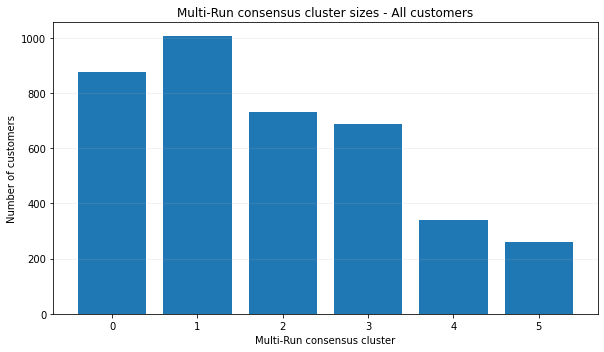

In [22]:
# =====================================================================
# FINAL VISUALIZATION OF ALL CUSTOMERS
# No sampling is used in these plots.
# =====================================================================

import matplotlib.pyplot as plt

X_vis = np.asarray(X_red_np)
y_vis = np.asarray(ensemble_labels_final, dtype=int)

if X_vis.shape[0] != y_vis.shape[0]:
    raise ValueError('Final labels and FAMD observations have different lengths.')

print('Number of customers visualized:', X_vis.shape[0])
print('Final number of clusters:', len(np.unique(y_vis)))

# 2D FAMD visualization.
plt.figure(figsize=(10, 7))
scatter_2d = plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=y_vis,
    s=18,
    alpha=0.70,
)
plt.xlabel('FAMD Component 1')
plt.ylabel('FAMD Component 2')
plt.title(f'All customers in FAMD space - Final ensemble ({len(np.unique(y_vis))} clusters)')
plt.grid(alpha=0.20)
plt.colorbar(scatter_2d, label='Final cluster')
plt.tight_layout()
plt.show()

# 3D FAMD visualization.
if X_vis.shape[1] >= 3:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter_3d = ax.scatter(
        X_vis[:, 0],
        X_vis[:, 1],
        X_vis[:, 2],
        c=y_vis,
        s=16,
        alpha=0.65,
    )
    ax.set_xlabel('FAMD Component 1')
    ax.set_ylabel('FAMD Component 2')
    ax.set_zlabel('FAMD Component 3')
    ax.set_title(
        f'All customers in 3D FAMD space - Final ensemble ({len(np.unique(y_vis))} clusters)'
    )
    fig.colorbar(scatter_3d, ax=ax, pad=0.10, label='Final cluster')
    plt.tight_layout()
    plt.show()

# Final cluster-size bar chart.
cluster_counts_plot = pd.Series(y_vis).value_counts().sort_index()
plt.figure(figsize=(8.5, 5))
bars = plt.bar(cluster_counts_plot.index.astype(str), cluster_counts_plot.values)
plt.xlabel('Final cluster')
plt.ylabel('Number of customers')
plt.title('Final cluster sizes - All customers')
plt.grid(axis='y', alpha=0.20)
for bar, count in zip(bars, cluster_counts_plot.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(count)),
        ha='center',
        va='bottom',
    )
plt.tight_layout()
plt.show()

# Compare main ensemble and Multi-Run consensus cluster sizes.
mr_cluster_counts = pd.Series(MR_ensemble_labels).value_counts().sort_index()
plt.figure(figsize=(8.5, 5))
plt.bar(mr_cluster_counts.index.astype(str), mr_cluster_counts.values)
plt.xlabel('Multi-Run consensus cluster')
plt.ylabel('Number of customers')
plt.title('Multi-Run consensus cluster sizes - All customers')
plt.grid(axis='y', alpha=0.20)
plt.tight_layout()
plt.show()


## Block 22: Optional exports and total runtime


In [23]:
EXPORT_RESULTS = False
EXPORT_DIR = Path("thesis_pipeline_outputs")

if EXPORT_RESULTS:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    out.to_csv(EXPORT_DIR / "customer_labels_final.csv", index=False)
    summary_df.to_csv(EXPORT_DIR / "metrics_summary.csv", index=False)
    ens_results_df.to_csv(EXPORT_DIR / "ensemble_k_scan.csv", index=False)
    cluster_sizes.to_csv(EXPORT_DIR / "cluster_sizes.csv", index=False)
    cluster_profile_num.to_csv(EXPORT_DIR / "cluster_profile_numeric.csv", index=False)
    cluster_profile_cat.to_csv(EXPORT_DIR / "cluster_profile_categorical.csv", index=False)
    MR_selected_partitions_df.to_csv(EXPORT_DIR / "multi_run_selected_partitions.csv", index=False)
    MR_results_df.to_csv(EXPORT_DIR / "multi_run_k_scan.csv", index=False)
    MR_algorithm_weight_summary.to_csv(EXPORT_DIR / "multi_run_algorithm_weights.csv", index=False)
    smoke_start_summary.to_csv(EXPORT_DIR / "smoke_hho_starts.csv", index=False)
    full_start_summary.to_csv(EXPORT_DIR / "full_hho_starts.csv", index=False)
    multirun_start_summary.to_csv(EXPORT_DIR / "multirun_hho_starts.csv", index=False)
    health_test_df.to_csv(EXPORT_DIR / "hho_health_test_fitness.csv", index=False)

PIPELINE_END_TIME = time.perf_counter()
PIPELINE_END_DATETIME = datetime.now()
elapsed = PIPELINE_END_TIME - PIPELINE_START_TIME

hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = elapsed % 60

print("\n==============================")
print("TOTAL PIPELINE RUNTIME")
print("==============================")
print("Started at :", PIPELINE_START_DATETIME.strftime("%Y-%m-%d %H:%M:%S"))
print("Finished at:", PIPELINE_END_DATETIME.strftime("%Y-%m-%d %H:%M:%S"))
print(f"Total time : {hours}h {minutes}m {seconds:.2f}s")



TOTAL PIPELINE RUNTIME
Started at : 2026-08-25 10:28:06
Finished at: 2026-08-25 14:46:38
Total time : 4h 18m 32.74s


## Block 23: Final pipeline consistency checks


In [24]:
# =====================================================================
# FINAL PIPELINE CONSISTENCY CHECKS
# =====================================================================

assert X_red_np.shape[0] == len(ensemble_labels_final)
assert len(smoke_best['runs']) == 20
assert all(len(r['trace']) == 60 for r in smoke_best['runs'])
assert len(full_best['runs']) == 30
assert all(len(r['trace']) == 160 for r in full_best['runs'])
assert len(multirun_hho['runs']) == 20
assert all(len(r['trace']) == 60 for r in multirun_hho['runs'])
assert np.isclose(np.sum(opt_w), 1.0)
assert len(MR_runs) == 20

print('All final pipeline consistency checks passed.')
print('Smoke starts:', len(smoke_best['runs']))
print('Full starts:', len(full_best['runs']))
print('Dedicated Multi-Run starts:', len(multirun_hho['runs']))
print('Final ensemble K:', bestK_final)
print('Multi-Run consensus K:', MR_bestK)
print('ARI(main, multi-run):', MR_vs_main_ARI)
print('NMI(main, multi-run):', MR_vs_main_NMI)


All final pipeline consistency checks passed.
Smoke starts: 20
Full starts: 30
Dedicated Multi-Run starts: 20
Final ensemble K: 6
Multi-Run consensus K: 6
ARI(main, multi-run): 1.0
NMI(main, multi-run): 1.0
